### Student Information
Name: 郭揉香

Student ID: 313700031

GitHub ID: Kuo-Jou-Hsiang

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their labels. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [11]:
### Begin Assignment Here
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt') # download the NLTK datasets
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
# If you get "ModuleNotFoundError: No module named 'PAMI'"
# run the following in a new Jupyter cell:
# !pip3 install PAMI
import PAMI
import umap

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kuojouhsiang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [12]:
df = pd.read_csv("/Users/kuojouhsiang/Documents/DM2025Labs./DM2025-Lab1-Exercise/newdataset/Reddit-stock-sentiment.csv")
df.head(10)

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0
9,comment,2021-12-31 16:29:49,hqp3kt4,stockstobuytoday,Any cheap stocks under $10?,Zumuru,https://www.reddit.com/r/stockstobuytoday/comm...,2,NaN,NaN,HLGN is $10. Hurry and catch it now before it ...,0.000000,0.000000,0.0,"['HLGN', 'Hurry', 'moon']",1.0


## 1.Data Preparation + Data Transformation

In [13]:
#保留要的欄位
df = df[['text','label']]
print(df.head(10))
print(len(df))

                                                text  label
0                                   Calls on retards   -1.0
1  Stunt as in like why did they even make a big ...    0.0
2                  Seeing lots of red in the ticker.    0.0
3  Vision Marine Technologies Inc. is rewriting t...    1.0
4                           He didn’t say thank you.   -1.0
5  Hoping to ejaculate in wet warm puss tonight, ...    0.0
6  Trump will respond to china increasing their t...   -1.0
7  Confirmed not a trap. Its been like this for p...    0.0
8  Am I the only one seeing the cup & handle brea...    1.0
9  HLGN is $10. Hurry and catch it now before it ...    1.0
847


In [14]:
#分測試集/訓練集，按標籤比例抽樣維持比例一致
from sklearn.model_selection import train_test_split
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=df['label'])
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

In [15]:
label_names = {
    -1.0: "negative",
     0.0: "neutral",
     1.0: "positive"
}

In [16]:
train_df['label_name'] = train_df['label'].map(label_names)
test_df['label_name'] = test_df['label'].map(label_names)

In [17]:
train_df["text"][5:10].tolist()

['I think we are past the numbers. Just assume folks world wide are now looking for another safe place to store their money.\n\nWe used to be the place. That is over.\n\nHell I am in the US and I am looking for a safer place to store my money.\n\nWe are in uncharted waters here and we have an economy that was already shaky to begin with.\n\nFar too many Americans are woefully unaware of how big the world is or how much we actually depend on them. \n\nLots of hard lessons to be learned going forward.\n\nTo sell bonds and treasuries we need people to believe their money is safe if they buy them. That idea is rapidly exiting stage right.\n\nI could be wrong but I think those rates are  screaming at us that we are going down rapidly as a trusted partner.',
 'it was amc day today. fsr after hrs',
 "Trump grossly miscalculated if he thought he could extort China. Even if you could someone prove the hurt to China will be much worse, and the reality is China has a lot of problems right now, th

In [18]:
list(label_names.values())

['negative', 'neutral', 'positive']

In [19]:
len(train_df.text)

677

In [20]:
train_df = train_df.reset_index(drop=True)
print("\n".join(train_df.loc[9, "text"].split("\n")))

Trump will respond to china increasing their tariffs. Trump is looking to fire Jerome Powell. Earnings reporting is starting. I personally think the next few weeks are going to be brutal.... if all companies adjust downwards and JPow is fired, i can see it going down A LOT and very quickly even


In [21]:
print("\n".join(train_df.iloc[9]["text"].split("\n")))

Trump will respond to china increasing their tariffs. Trump is looking to fire Jerome Powell. Earnings reporting is starting. I personally think the next few weeks are going to be brutal.... if all companies adjust downwards and JPow is fired, i can see it going down A LOT and very quickly even


In [22]:
print(label_names[train_df.label[0]])

neutral


In [23]:
train_df.label[0]

np.float64(0.0)

In [24]:
train_df.label[0:10]

0    0.0
1   -1.0
2    0.0
3    1.0
4    1.0
5   -1.0
6    0.0
7   -1.0
8   -1.0
9   -1.0
Name: label, dtype: float64

In [25]:
for t in train_df.label[:10]:
    print(label_names[t])

neutral
negative
neutral
positive
positive
negative
neutral
negative
negative
negative


### **>>> Exercise 1**
print出前三個在dataset中的樣本

In [26]:
for i in range(3):
    print(f'sample {i+1}')
    print("\n".join(train_df.text[i].split("\n")))

sample 1
Disgusting tactics
sample 2
Cope harder
sample 3
# Stock winners



**11.65% GameStop**

** Earnings report - GameStop knows what its investors want. CEO Ryan Cohen’s latest move to revive the struggling video game retailer is putting its $4.8 billion cash reserve into Bitcoin—following in MicroStrategy’s footsteps. (**[**CNBC**]()**)**



**5.25% Nintendo**

**Rumors are flying that the video game company could launch the Switch 2 as soon as June. It’s the updated version of its hugely successful Switch console, first released in 2017. Some reports say a full reveal could happen as early as next week, and investors are expecting big sales. (**[**Sherwood**](/)**)**



**3.08% Dollar Tree**

** Earnings report - The discount retail chain is selling off Family Dollar for $1 billion, nearly a decade after buying it for $9 billion. The chain never quite fit in and struggled to compete with bigger players. Investors seem relieved to see Dollar Tree cut its losses and refocus on it

In [27]:
print(train_df)

                                                  text  label label_name
0                                   Disgusting tactics    0.0    neutral
1                                          Cope harder   -1.0   negative
2    # Stock winners\n\n\n\n**11.65% GameStop**\n\n...    0.0    neutral
3                          DOGE is going up today 153%    1.0   positive
4    So they went from saying redditors are bad for...    1.0   positive
..                                                 ...    ...        ...
672  Bull thesis comes down to buying a company wit...    0.0    neutral
673  Worse how?  We have STRONG evidence Trump does...    1.0   positive
674  This is like a pissing contest between Xi and ...    0.0    neutral
675  Hey guys! Currently on vacation which has been...    0.0    neutral
676  There's going to be 4 years of this shit. How ...   -1.0   negative

[677 rows x 3 columns]


檢查 **train_df** 資料型態是否為 DataFrame 

In [28]:
type(train_df)

pandas.core.frame.DataFrame

In [29]:
train_df[0:2]

,text,label,label_name
0,Disgusting tactics,0.0,neutral
1,Cope harder,-1.0,negative


In [30]:
for t in train_df["text"][:2]:
    print(t)

Disgusting tactics
Cope harder


In [31]:
train_df[:10][["text","label_name"]]

,text,label_name
0,Disgusting tactics,neutral
1,Cope harder,negative
2,# Stock winners\n\n\n\n**11.65% GameStop**\n\n...,neutral
3,DOGE is going up today 153%,positive
4,So they went from saying redditors are bad for...,positive
5,I think we are past the numbers. Just assume f...,negative
6,it was amc day today. fsr after hrs,neutral
7,Trump grossly miscalculated if he thought he c...,negative
8,It's basically just bickering with math at thi...,negative
9,Trump will respond to china increasing their t...,negative


In [32]:
train_df[-10:]

,text,label,label_name
667,He woke up a sleeping giant,0.0,neutral
668,Crazy how A meme coin is worth more than slive...,1.0,positive
669,It was so blatant. In a normal version of the...,-1.0,negative
670,If Trump is allowed to control the fed we will...,-1.0,negative
671,Position?,0.0,neutral
672,Bull thesis comes down to buying a company wit...,0.0,neutral
673,Worse how? We have STRONG evidence Trump does...,1.0,positive
674,This is like a pissing contest between Xi and ...,0.0,neutral
675,Hey guys! Currently on vacation which has been...,0.0,neutral
676,There's going to be 4 years of this shit. How ...,-1.0,negative


In [33]:
# using loc (by label)
train_df.loc[:10, 'text']

0                                    Disgusting tactics
1                                           Cope harder
2     # Stock winners\n\n\n\n**11.65% GameStop**\n\n...
3                           DOGE is going up today 153%
4     So they went from saying redditors are bad for...
5     I think we are past the numbers. Just assume f...
6                   it was amc day today. fsr after hrs
7     Trump grossly miscalculated if he thought he c...
8     It's basically just bickering with math at thi...
9     Trump will respond to china increasing their t...
10                Emoluments clause? lol. What is that?
Name: text, dtype: object

In [34]:
# using iloc (by position)
train_df.iloc[:10, 0:]

,text,label,label_name
0,Disgusting tactics,0.0,neutral
1,Cope harder,-1.0,negative
2,# Stock winners\n\n\n\n**11.65% GameStop**\n\n...,0.0,neutral
3,DOGE is going up today 153%,1.0,positive
4,So they went from saying redditors are bad for...,1.0,positive
5,I think we are past the numbers. Just assume f...,-1.0,negative
6,it was amc day today. fsr after hrs,0.0,neutral
7,Trump grossly miscalculated if he thought he c...,-1.0,negative
8,It's basically just bickering with math at thi...,-1.0,negative
9,Trump will respond to china increasing their t...,-1.0,negative


### **>>> Exercise 2**
其他檢索方法-用 boolean方式過濾資料

In [35]:
train_df[train_df['label'] > 0]

,text,label,label_name
3,DOGE is going up today 153%,1.0,positive
4,So they went from saying redditors are bad for...,1.0,positive
11,The obvious can also be refreshing from CNBC: ...,1.0,positive
15,Entered yesterday 2-9-24. Fortunately I entere...,1.0,positive
16,I think it’s gonna work itself out. I bought t...,1.0,positive
...,...,...,...
636,$ATUS at a huge discount right now. Just CRUSH...,1.0,positive
639,I'm happy for him.,1.0,positive
661,The Chinese likely hold these bonds in many di...,1.0,positive
668,Crazy how A meme coin is worth more than slive...,1.0,positive


### **>>> Exercise 3**
fetch records belonging to the ```neutral``` label, and query every 10th record. Only show the first 5 records

In [36]:
train_df[train_df['label_name']=='neutral'][::10][0:5]

,text,label,label_name
0,Disgusting tactics,0.0,neutral
26,CGC,0.0,neutral
40,"NIPU:\n\nThis randomized, multi-center phase I...",0.0,neutral
53,I decided to simplify my Roth as I've gotten c...,0.0,neutral
68,Premarket Gainers for Today\n\n [Stock Invest ...,0.0,neutral


## 3. Data Mining using Pandas

In [37]:
import pandas as pd

# my functions
import helpers.data_mining_helpers as dmh

### 3.1 Missing Values

In [38]:
# check missing values
train_df.isnull()

,text,label,label_name
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
672,False,False,False
673,False,False,False
674,False,False,False
675,False,False,False


In [39]:
train_df.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,label,label_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0


### >>> **Exercise 4 :** 
calculate the missing values in every record instead of every column

In [40]:
# Answer here
train_df.isnull().apply(lambda x: dmh.check_missing_values(x), axis=1)

0      (The amoung of missing records is: , 0)
1      (The amoung of missing records is: , 0)
2      (The amoung of missing records is: , 0)
3      (The amoung of missing records is: , 0)
4      (The amoung of missing records is: , 0)
                        ...                   
672    (The amoung of missing records is: , 0)
673    (The amoung of missing records is: , 0)
674    (The amoung of missing records is: , 0)
675    (The amoung of missing records is: , 0)
676    (The amoung of missing records is: , 0)
Length: 677, dtype: object

### 3.2 insert dummy data into the dataframe

In [41]:
dummy_series = pd.Series(["dummy_record", 1.0], index=["text", "label"])

In [42]:
dummy_series

text     dummy_record
label             1.0
dtype: object

In [43]:
dummy_series.to_frame().T
# .to_frame() -> Convert Series to DataFrame
# .T          -> Transpose

,text,label
0,dummy_record,1.0


In [44]:
result_with_series = pd.concat([train_df, dummy_series.to_frame().T], ignore_index=True)

In [45]:
# check if the records was commited into result
len(result_with_series)

678

In [46]:
result_with_series.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,label,label_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,1


In [47]:
# dummy record as dictionary format
dummy_dict = [{'text': 'dummy_record',
               'label': 1
              }]

In [48]:
train_df = pd.concat([train_df, pd.DataFrame(dummy_dict)], ignore_index=True)

In [49]:
len(train_df)

678

In [50]:
train_df.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,label,label_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,1


In [51]:
train_df.dropna(inplace=True)

In [52]:
train_df.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,label,label_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0


In [53]:
len(train_df)

677

## 4.  Data Preprocessing


### 4.1 Sampling


In [54]:
train_df_sample = train_df.sample(n=500) 

In [55]:
len(train_df_sample)

500

In [56]:
train_df_sample[0:5]

,text,label,label_name
490,Who is the dumbass not asking for second opini...,-1.0,negative
590,I think it’s way past time for me to remove my...,1.0,positive
410,"I'm on my way into work, all my coworkers are ...",0.0,neutral
422,That was the most obvious bull trap in history...,-1.0,negative
24,The bond market\n/,0.0,neutral


### **>>> Exercise 6 :**
觀察抽樣前後的差異

In [57]:
# Answer here
# 觀察原始資料和樣本資料的形狀
print("train_df shape:", train_df.shape)
print("train_df_sample shape:", train_df_sample.shape)
#觀察原始資料和樣本資料前10筆資料分類
print("Xtrain_df 前10筆資料分類")
for t in range(10):
    print(train_df['label_name'].iloc[i])
print("X_sample 前10筆資料分類")
for i in range(10):
    print(train_df_sample['label_name'].iloc[i])

train_df shape: (677, 3)
train_df_sample shape: (500, 3)
Xtrain_df 前10筆資料分類
neutral
neutral
neutral
neutral
neutral
neutral
neutral
neutral
neutral
neutral
X_sample 前10筆資料分類
negative
positive
neutral
negative
neutral
neutral
negative
positive
negative
neutral


In [58]:
import matplotlib.pyplot as plt
%matplotlib inline

label_name
neutral     338
negative    252
positive     87
Name: count, dtype: int64


<Axes: title={'center': 'Label distribution'}, xlabel='label_name'>

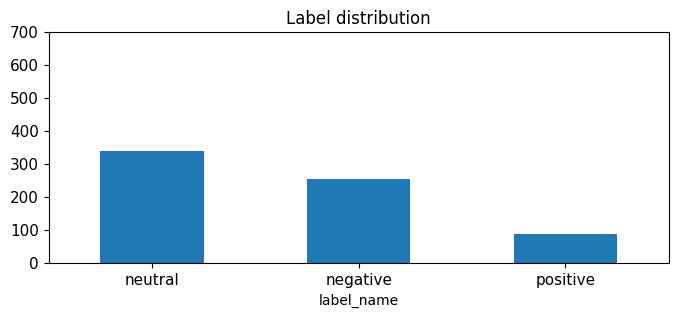

In [59]:
print(train_df.label_name.value_counts())

# plot barchart for X
train_df.label_name.value_counts().plot(kind = 'bar',
                                    title = 'Label distribution',
                                    ylim = [0, 700],        
                                    rot = 0, fontsize = 11, figsize = (8,3))

label_name
neutral     240
negative    198
positive     62
Name: count, dtype: int64


<Axes: title={'center': 'Label distribution'}, xlabel='label_name'>

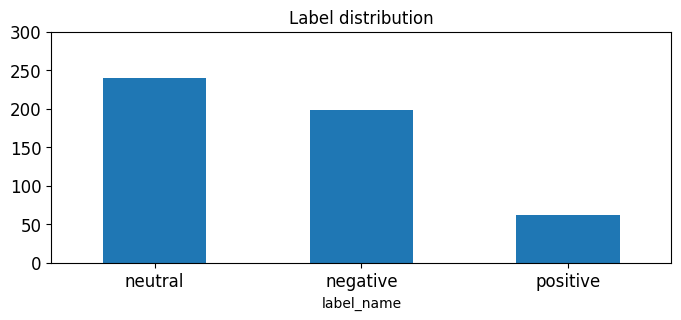

In [60]:
print(train_df_sample.label_name.value_counts())

# plot barchart for X_sample
train_df_sample.label_name.value_counts().plot(kind = 'bar',
                                           title = 'Label distribution',
                                           ylim = [0, 300], 
                                           rot = 0, fontsize = 12, figsize = (8,3))

### >>> **Exercise 7 :**
y軸刻度隨著次數增加調整

<Axes: title={'center': 'Label distribution'}, xlabel='label_name'>

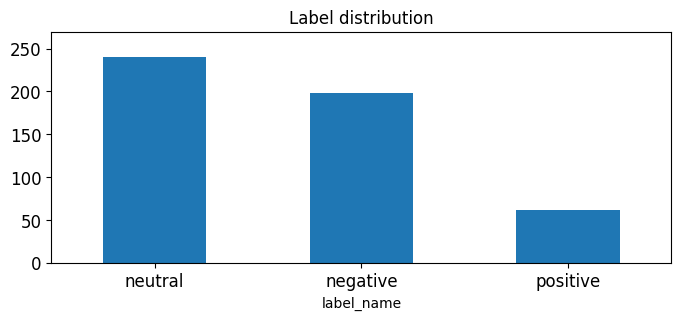

In [61]:
# Answer here
train_df_sample.label_name.value_counts().plot(kind = 'bar',
                                           title = 'Label distribution',
                                           ylim = [0,train_df_sample.label_name.value_counts().max()+30 ], 
                                           rot = 0, fontsize = 12, figsize = (8,3))

### >>> **Exercise 8：**
視覺化抽樣前後資料分布的差異-繪製到同一張圖

            train_df_label_name  train_df_samplecategory_name
label_name                                                   
neutral                     338                           240
negative                    252                           198
positive                     87                            62


<Axes: title={'center': 'Label distribution'}, xlabel='label_name'>

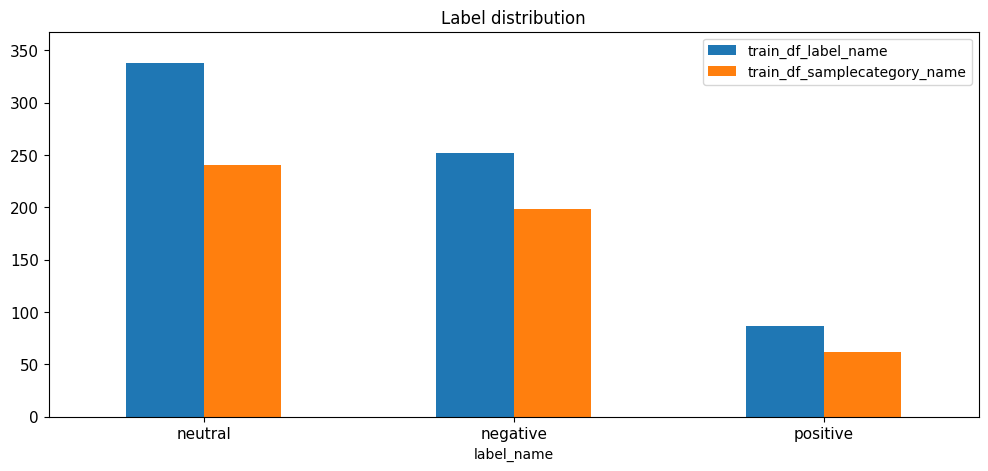

In [62]:
df_plot = pd.DataFrame({
    'train_df_label_name': train_df['label_name'].value_counts(),
    'train_df_samplecategory_name': train_df_sample['label_name'].value_counts()
}).fillna(0).astype(int)
print(df_plot)
df_plot.plot(kind = 'bar',
            title = 'Label distribution',
            ylim = [0,train_df.label_name.value_counts().max()+30 ], 
            rot = 0, fontsize = 11, figsize = (12,5))

### 4.2 Feature Creation


In [63]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kuojouhsiang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kuojouhsiang/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [64]:
# takes a like a minute or two to process

train_df['unigrams'] = train_df['text'].apply(lambda x: dmh.tokenize_text(x))

#dmh.tokenize_text:先把文章切成句子，再把句子切成單字

In [65]:
train_df[0:4]["unigrams"]

0                                [Disgusting, tactics]
1                                       [Cope, harder]
2    [#, Stock, winners, *, *, 11.65, %, GameStop, ...
3                 [DOGE, is, going, up, today, 153, %]
Name: unigrams, dtype: object

In [66]:
train_df[0:4]

,text,label,label_name,unigrams
0,Disgusting tactics,0.0,neutral,"[Disgusting, tactics]"
1,Cope harder,-1.0,negative,"[Cope, harder]"
2,# Stock winners\n\n\n\n**11.65% GameStop**\n\n...,0.0,neutral,"[#, Stock, winners, *, *, 11.65, %, GameStop, ..."
3,DOGE is going up today 153%,1.0,positive,"[DOGE, is, going, up, today, 153, %]"


In [67]:
list(train_df[0:1]['unigrams'])

[['Disgusting', 'tactics']]

### 4.3 Feature subset selection


In [68]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
train_df_counts = count_vect.fit_transform(train_df.text) 
print(train_df_counts[0:10])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 474 stored elements and shape (10, 3837)>
  Coords	Values
  (0, 1051)	1
  (0, 3338)	1
  (1, 841)	1
  (1, 1620)	1
  (2, 3229)	2
  (2, 3759)	1
  (2, 15)	1
  (2, 121)	1
  (2, 1491)	2
  (2, 1134)	2
  (2, 2832)	2
  (2, 1968)	1
  (2, 3722)	1
  (2, 1907)	5
  (2, 1883)	3
  (2, 3675)	2
  (2, 651)	1
  (2, 2935)	1
  (2, 743)	1
  (2, 1991)	1
  (2, 2255)	1
  (2, 3450)	10
  (2, 2881)	1
  (2, 3395)	12
  (2, 3258)	1
  :	:
  (9, 3396)	1
  (9, 1091)	1
  (9, 3510)	2
  (9, 1244)	1
  (9, 3753)	1
  (9, 2092)	1
  (9, 603)	1
  (9, 2852)	1
  (9, 1803)	1
  (9, 1383)	1
  (9, 1920)	1
  (9, 2602)	1
  (9, 2833)	1
  (9, 3207)	1
  (9, 2513)	1
  (9, 1366)	1
  (9, 3710)	1
  (9, 558)	1
  (9, 249)	1
  (9, 776)	1
  (9, 1096)	1
  (9, 1933)	1
  (9, 1384)	1
  (9, 3641)	1
  (9, 2716)	1


In [69]:
count_vect.get_feature_names_out()[1051]

'disgusting'

In [70]:
count_vect.get_feature_names_out()[2832]

'report'

In [71]:
analyze = count_vect.build_analyzer()
analyze("I am craving for a hawaiian pizza right now")

# tokenization, remove stop words (e.g i, a, the), create n-gram (or unigram)

['am', 'craving', 'for', 'hawaiian', 'pizza', 'right', 'now']

### **>>> Exercise 9 :**
turn  text document into a tokenized text using the build_analyzer()

In [72]:
analyze(train_df.text[0])

['disgusting', 'tactics']

In [73]:
analyze(train_df.text[2])

['stock',
 'winners',
 '11',
 '65',
 'gamestop',
 'earnings',
 'report',
 'gamestop',
 'knows',
 'what',
 'its',
 'investors',
 'want',
 'ceo',
 'ryan',
 'cohen',
 'latest',
 'move',
 'to',
 'revive',
 'the',
 'struggling',
 'video',
 'game',
 'retailer',
 'is',
 'putting',
 'its',
 'billion',
 'cash',
 'reserve',
 'into',
 'bitcoin',
 'following',
 'in',
 'microstrategy',
 'footsteps',
 'cnbc',
 '25',
 'nintendo',
 'rumors',
 'are',
 'flying',
 'that',
 'the',
 'video',
 'game',
 'company',
 'could',
 'launch',
 'the',
 'switch',
 'as',
 'soon',
 'as',
 'june',
 'it',
 'the',
 'updated',
 'version',
 'of',
 'its',
 'hugely',
 'successful',
 'switch',
 'console',
 'first',
 'released',
 'in',
 '2017',
 'some',
 'reports',
 'say',
 'full',
 'reveal',
 'could',
 'happen',
 'as',
 'early',
 'as',
 'next',
 'week',
 'and',
 'investors',
 'are',
 'expecting',
 'big',
 'sales',
 'sherwood',
 '08',
 'dollar',
 'tree',
 'earnings',
 'report',
 'the',
 'discount',
 'retail',
 'chain',
 'is',
 '

In [74]:
# We can check the shape of this matrix by:
train_df_counts.shape

(677, 3837)

In [75]:
# We can obtain the feature names of the vectorizer, i.e., the terms
# usually on the horizontal axis
count_vect.get_feature_names_out()[0:10]

array(['00', '000', '01378', '02', '027', '03', '08', '10', '100', '1000'],
      dtype=object)

In [76]:
# we convert from sparse array to normal array
train_df_counts[0:5, 0:100].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,

In [77]:
count_vect.get_feature_names_out()[6]

'08'

### **>>> Exercise 10 :**
another `1` in the same record


In [78]:
count_vect.get_feature_names_out()[15]

'11'

In [79]:
plot_x = ["term_"+str(i) for i in count_vect.get_feature_names_out()[0:20]]

In [80]:
plot_y = ["doc_"+ str(i) for i in list(train_df.index)[0:20]]

In [81]:
plot_z = train_df_counts[0:20, 0:20].toarray() #X_counts[how many documents, how many terms]

In [82]:
plot_z

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

### 4.4Visulization

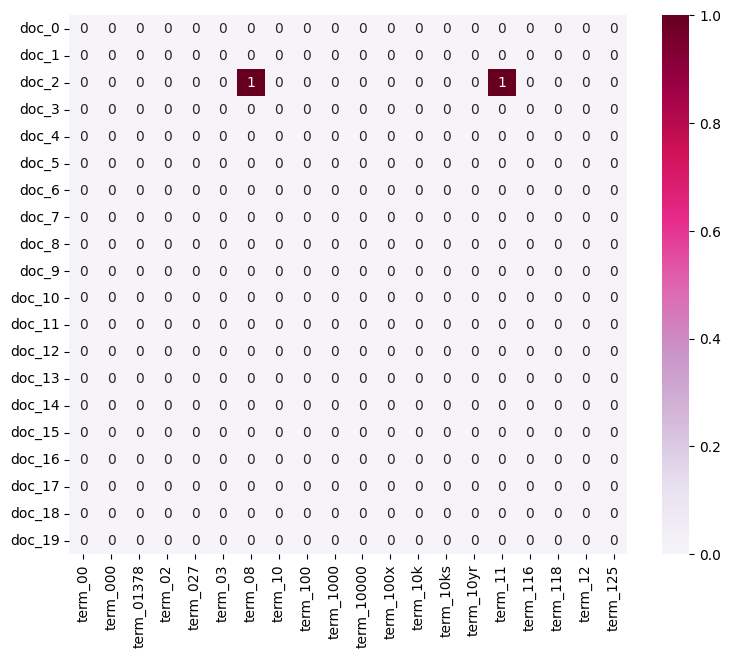

In [83]:
import seaborn as sns

df_todraw = pd.DataFrame(plot_z, columns = plot_x, index = plot_y)
plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_todraw,
                 cmap="PuRd",
                 vmin=0, vmax=1, annot=True)

### **>>> Exercise 11 :** 
1.改用TFIDF方式反映詞的權重

2.隨機抽樣30*30的樣本

3.熱力圖中格子內的數字代表某個詞在某篇文中的TFIDF權重，0表示該字詞在文章中沒有出現，數字越大代表在文章中越重要

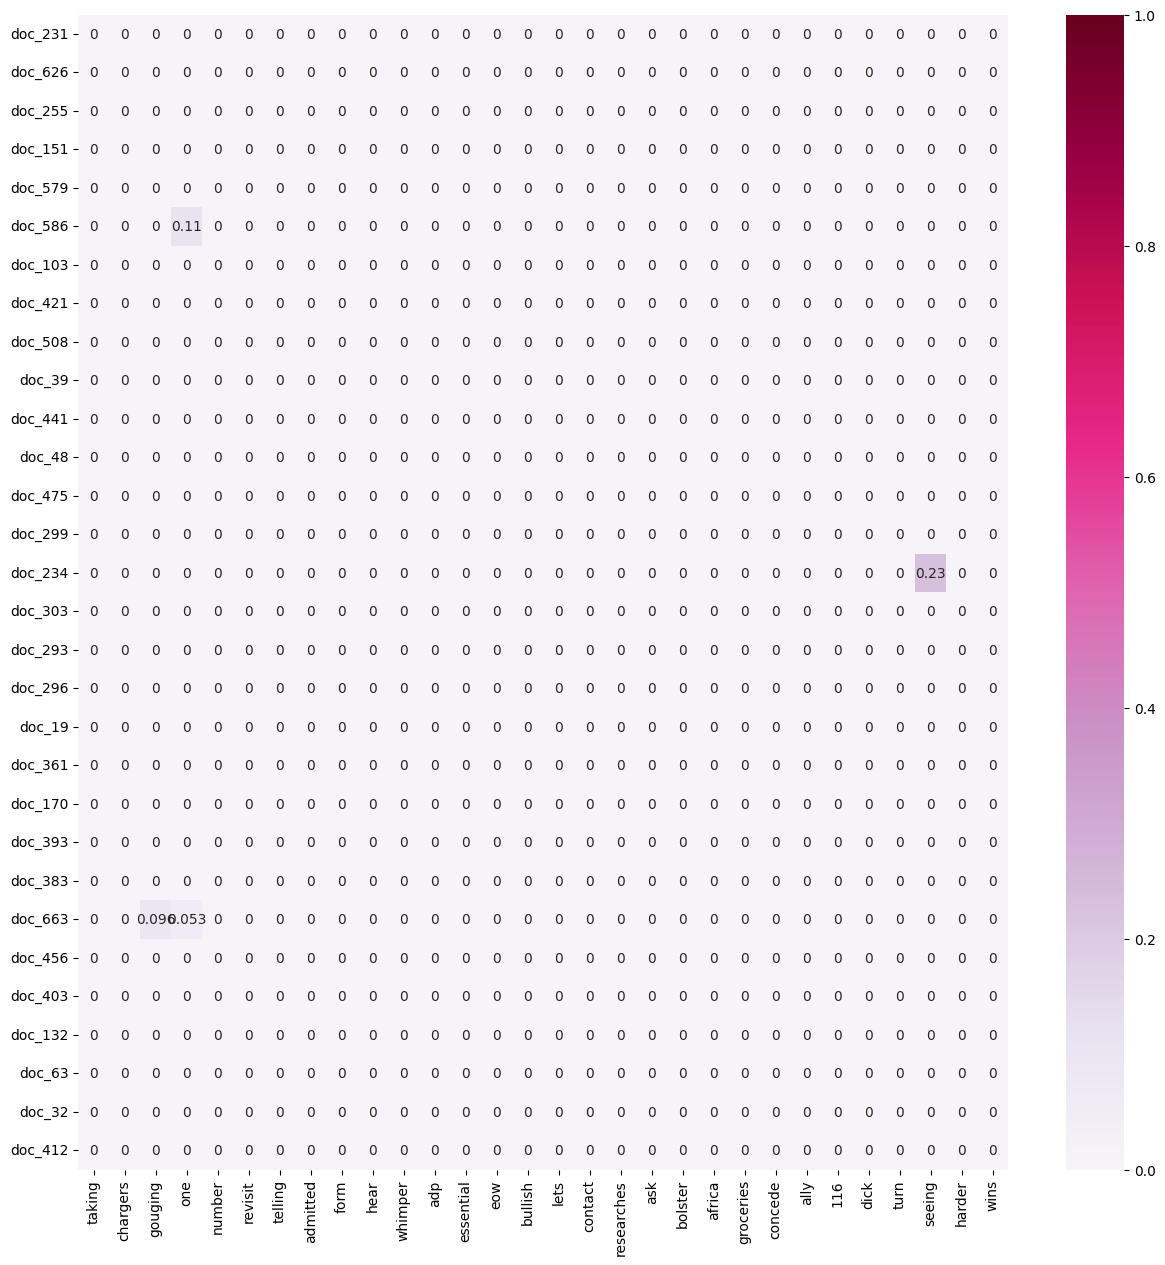

In [84]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
train_df_tfidf = tfidf.fit_transform(train_df_counts)  
vocab = count_vect.get_feature_names_out()

docs_sample = 30
terms_sample = 30
rows = np.random.choice(train_df_tfidf.shape[0], docs_sample, replace=False)
cols = np.random.choice(train_df_tfidf.shape[1], terms_sample, replace=False)
matrix = train_df_tfidf[rows,:][:,cols].toarray()
doc_labels = [f"doc_{i}" for i in rows]      
term_labels = vocab[cols] 

plot_tfidf = pd.DataFrame(matrix, columns =term_labels, index=doc_labels)
plt.subplots(figsize=(15,15))
ax = sns.heatmap(plot_tfidf,
                 cmap="PuRd",
                 vmin=0, vmax=1,annot=True)

### 4.5 Attribute Transformation / Aggregation
###  4.5.1 Transform Text Data

計算詞頻


In [85]:
term_frequencies = []
for j in range(0,train_df_counts.shape[1]):
    term_frequencies.append(sum(train_df_counts[:,j].toarray()))

In [86]:
term_frequencies = np.asarray(train_df_counts.sum(axis=0))[0]

In [87]:
term_frequencies[0] #sum of first term: 00

np.int64(3)

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/3480579971.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);


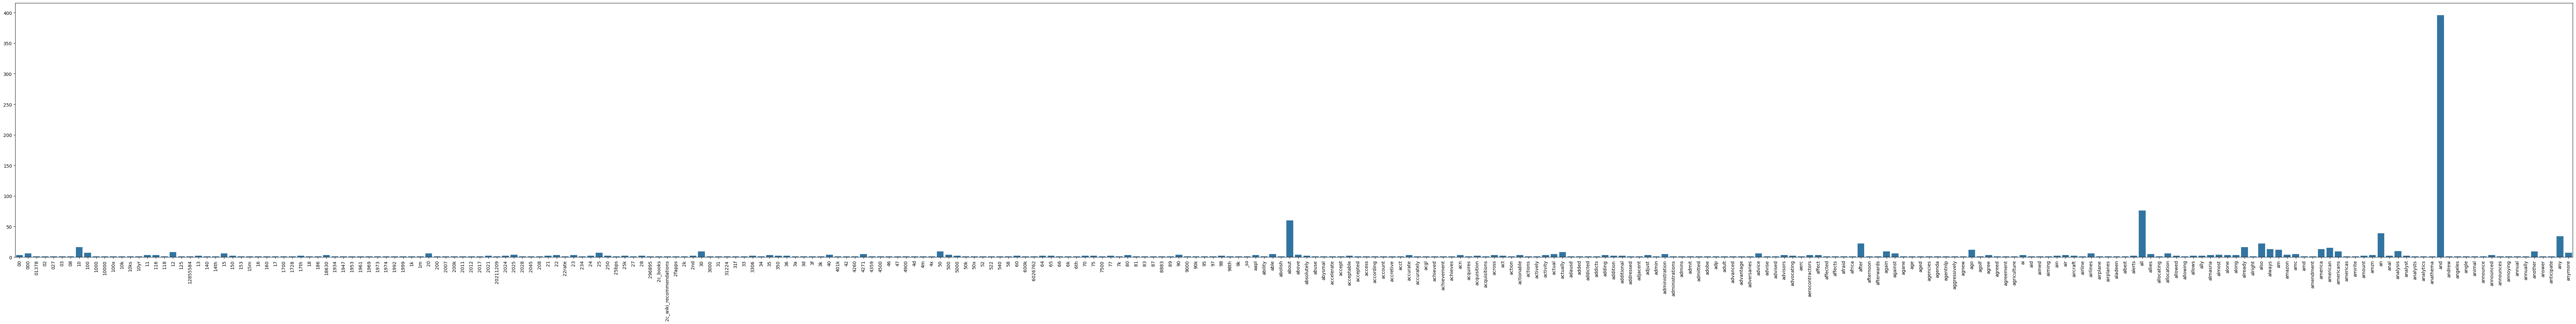

In [88]:
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect.get_feature_names_out()[:300], 
            y=term_frequencies[:300])
g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);

### >>> **Exercise 12 :**
用ploty 繪製圖形

In [89]:
import plotly.express as pe
x_freq = count_vect.get_feature_names_out()[:300]
y_freq = term_frequencies[:300]
df = pd.DataFrame({"term": x_freq, "freq": y_freq})
h = pe.bar(df, x= 'term', y='freq', title="Term frequencies",labels={"term": "Term", "freq": "Frequency"})
h.update_layout(xaxis_tickangle=-90, width=1600, height=500, bargap=0.2)

### >>> **Exercise 13 :** 
efficiently reduce the number of terms

1.過濾常出現或不常出現的單詞

2.計算詞頻後，依詞頻高低排序，取前50個

In [90]:
K = 50
count_vect = CountVectorizer(stop_words='english', max_df=0.5, min_df=5)
train_df_counts = count_vect.fit_transform(train_df.text) 
term_freq = np.asarray(train_df_counts.sum(axis=0)).ravel()   
topk_idex = term_freq.argsort()[::-1][:K]
x_freq   = count_vect.get_feature_names_out()[topk_idex]
y_freq   = term_freq[topk_idex]
df = pd.DataFrame({"term": x_freq, "freq": y_freq})
h = pe.bar(df, x= 'term', y='freq', title="Term frequencies",labels={"term": "Term", "freq": "Frequency"})
h.update_layout(xaxis_tickangle=-90, width=1600, height=500, bargap=0.2)

### >>> **Exercise 14 :** 
長尾分布圖

1.做TFIDF，計算IDF

2.找出平均TFIDF權重前K高個的字詞

3.建一個DF，按照權重大小排序

In [91]:
K = 100
tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
train_df_tfidf = tfidf.fit_transform(train_df_counts)
mean_tfidf = np.array(train_df_tfidf.mean(axis=0)).ravel()
topk_idex = mean_tfidf.argsort()[::-1][:K]    
vocab = count_vect.get_feature_names_out()
df_topk = pd.DataFrame({
    "term": vocab[topk_idex],
    "score": mean_tfidf[topk_idex]
}).sort_values("score", ascending=False)
k= pe.bar(df_topk, x="term", y="score", orientation="v",
             title=f"Top {K} Terms",
             labels=({"score":"Score","term":"Term"}))
k.update_layout(height=900)

transform the values in that vector into the log distribution

In [92]:
import math
term_frequencies_log = [math.log(i) for i in term_frequencies]

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/2166548998.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



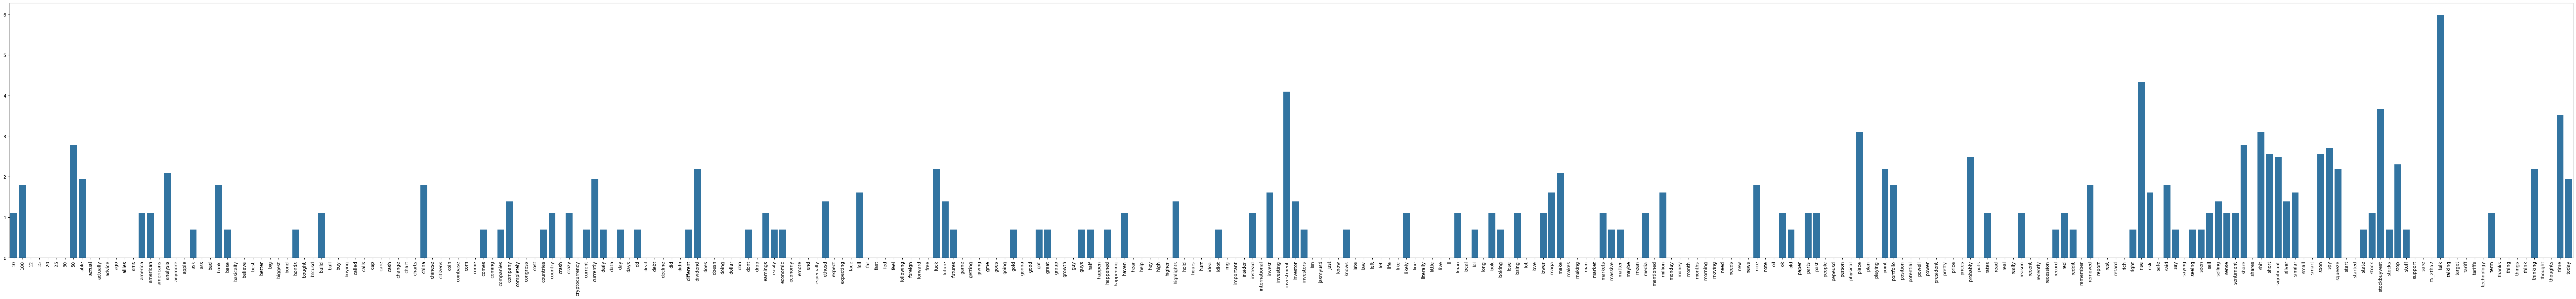

In [93]:
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect.get_feature_names_out()[:300],
                y=term_frequencies_log[:300])
g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);

### >>> **Exercise 15 :** 

Y軸單位從次數改成LOG(次)，LOG的函數性質可以有效改善詞頻分布差異大的問題。

在原始詞頻分布中只有很少數的詞出現頻率很高，大部分的詞只出現少次，導致在原始分布中低頻率的詞幾乎看不出差別。

透過LOG函數轉換可以把高頻率壓縮、小頻率放大，改善長尾效果

In [94]:
import plotly.express as pe
term_frequencies_log = [math.log(i) for i in term_frequencies]
x_freq = count_vect.get_feature_names_out()[:300]
y_freq = term_frequencies_log[:300]
df = pd.DataFrame({"term": x_freq, "freq": y_freq})
df = df.sort_values("freq", ascending=False)
h = pe.bar(df, x= 'term', y='freq', title="Term frequencies",labels={"term": "Term", "freq": "Frequency"})
h.update_layout(xaxis_tickangle=-90, width=1600, height=500, bargap=0.2)

# Phase 2

###  4.5.2 Finding frequent patterns


In [95]:
### Begin Assignment Here
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

#Create separate DataFrames for each label
labels = train_df['label_name'].unique()  
label_dfs = {}  

for label in labels:
    # Filter the original DataFrame by label
    label_dfs[label] = train_df[train_df['label_name'] == label].copy()

# Function to create term-document frequency DataFrame for each label
def create_term_document_df(df):
    count_vect = CountVectorizer()  
    train_df_counts = count_vect.fit_transform(df['text'])  
    
    # Get the unique words (vocabulary) from the vectorizer
    words = count_vect.get_feature_names_out()
    
    # Create a DataFrame where rows are documents and columns are words
    term_document_df = pd.DataFrame(train_df_counts.toarray(), columns=words)
    
    return term_document_df

# Create term-document frequency DataFrames for each label
filt_term_document_dfs = {}  
for label in labels:
    filt_term_document_dfs[label] = create_term_document_df(label_dfs[label])

In [96]:
# Display the filtered DataFrame for one of the labels, feel free to change the number in the vector
label_number=1 #You can change it from 0 to 3
print(f"Filtered Term-Document Frequency DataFrame for Label {labels[label_number]}:")
filt_term_document_dfs[labels[label_number]]

Filtered Term-Document Frequency DataFrame for Label negative:


,000,02,03,10,1000,10000,11,12,13,14th,...,year,years,yet,yields,yippee,yo,you,your,yourselves,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
248,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
249,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
250,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 觀察各類別的詞頻分佈

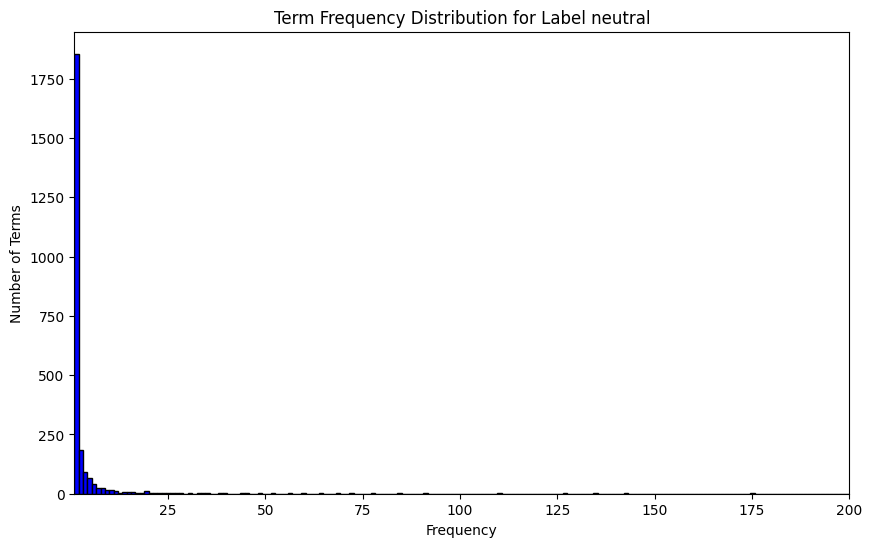

In [97]:
 # Sum over all documents to get total frequency for each word
label_number=0 
word_counts = filt_term_document_dfs[labels[label_number]].sum(axis=0).to_numpy()
 
# Visualize the frequency distribution
plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=300, color='blue', edgecolor='black')
plt.title(f'Term Frequency Distribution for Label {labels[label_number]}')
plt.xlabel('Frequency')
plt.ylabel('Number of Terms')
plt.xlim(1, 200)
plt.show()

### 找出最常出現的前5％詞

In [98]:
label_number=0
word_counts = filt_term_document_dfs[labels[label_number]].sum(axis=0).to_numpy()

# Sort the term frequencies in descending order
sorted_indices = np.argsort(word_counts)[::-1]  # Get indices of sorted frequencies
sorted_counts = np.sort(word_counts)[::-1]  # Sort frequencies in descending order

# Calculate the index corresponding to the top 5% most frequent terms
total_terms = len(sorted_counts)
top_5_percent_index = int(0.05 * total_terms)

# Get the indices of the top 5% most frequent terms
top_5_percent_indices = sorted_indices[:top_5_percent_index]

# Filter terms that belong to the top 5% based on their rank
filtered_words = [filt_term_document_dfs[labels[label_number]].iloc[:, i].name for i in top_5_percent_indices]

print(f"Label: {labels[label_number]}")
print(f"Number of terms in top 5%: {top_5_percent_index}")
print(f"Filtered terms: {filtered_words}")


Label: neutral
Number of terms in top 5%: 121
Filtered terms: ['the', 'to', 'and', 'it', 'of', 'is', 'in', 'that', 'you', 'for', 'on', 'this', 'market', 'are', 'they', 'if', 'with', 'as', 'was', 'not', 'my', 'be', 'or', 'like', 'what', 'but', 'all', 'at', 'so', 'stock', 'he', 'just', 'can', 'have', 'about', 'us', 'do', 'from', 'will', 'your', 'x200b', 're', 'price', 'there', 'how', 'some', 'futures', 'more', 'up', 'an', 'has', 'money', 'one', 'their', 'no', 'by', 'we', 'want', 'people', 'why', 'now', 'any', 'com', 'stockbuyvest', 'company', 'were', 'into', 'would', 'trump', 'china', 'see', 'them', 'good', 'think', 'out', 'even', 'when', 'today', 'first', 'stocks', 'going', 'does', 'who', 'other', 'only', 'year', '10', 'new', 'don', 'did', 'could', 'been', 'call', 'its', 'silver', 'always', 'investors', 'too', 'me', 'then', 'than', 'right', 'get', 'which', 'because', 'years', 'know', 'portfolio', 'day', 'lower', 'down', 'also', 'since', 'updated', 'may', 'off', 'should', 'daily', 'here'

In [99]:
sorted_counts 

array([337, 223, 175, ...,   1,   1,   1], shape=(2421,))

In [100]:
sorted_indices

array([2129, 2168,  183, ..., 1437, 1439, 1210], shape=(2421,))

In [101]:
#Here we can sum up the column corresponding to the top 5% words, we just specify which one first.
filt_term_document_dfs[labels[label_number]].loc[:,'the'].sum(axis=0)

np.int64(337)

### 找出最不常出現的前1％詞

In [102]:
label_number=0 #You can change it from 0 to 3
word_counts = filt_term_document_dfs[labels[label_number]].sum(axis=0).to_numpy()

# Sort the term frequencies in ascending order and get sorted indices
sorted_indices = np.argsort(word_counts)  # Get indices of sorted frequencies
sorted_counts = word_counts[sorted_indices]  # Sort frequencies

# Calculate the index corresponding to the bottom 1% least frequent terms
total_terms = len(sorted_counts)
bottom_1_percent_index = int(0.01 * total_terms)

# Get the indices of the bottom 1% least frequent terms
bottom_1_percent_indices = sorted_indices[:bottom_1_percent_index]

# Filter terms that belong to the bottom 1% based on their rank
filtered_words = [filt_term_document_dfs[labels[label_number]].iloc[:, i].name for i in bottom_1_percent_indices]

print(f"Label: {labels[label_number]}")
print(f"Number of terms in bottom 1%: {bottom_1_percent_index}")
print(f"Filtered terms: {filtered_words}")

Label: neutral
Number of terms in bottom 1%: 24
Filtered terms: ['jeep', 'nacs', 'myers', 'mutual', 'muscles', 'multiple', 'multikine', 'multi', 'msci', 'mpm', 'movies', 'mouth', 'nah', 'mou', 'moderators', 'models', 'moar', 'mission', 'missing', 'miran', 'minutes', 'miners', 'minds', 'mind']


In [103]:
sorted_counts 

array([  1,   1,   1, ..., 175, 223, 337], shape=(2421,))

In [104]:
sorted_indices

array([1210, 1439, 1437, ...,  183, 2168, 2129], shape=(2421,))

In [105]:
#Here we can sum up the column corresponding to the bottom 1% words, we just specify which one first.
filt_term_document_dfs[labels[label_number]].loc[:,'mutual'].sum(axis=0) 

np.int64(1)

### 過濾掉高頻與低頻詞

In [106]:
label_number=0 #You can change it from 0 to 3

# Filter the bottom 1% and top 5% words based on their sum across all documents
def filter_top_bottom_words_by_sum(term_document_df, top_percent=0.05, bottom_percent=0.01):
    # Calculate the sum of each word across all documents
    word_sums = term_document_df.sum(axis=0)
    
    # Sort the words by their total sum
    sorted_words = word_sums.sort_values()
    
    # Calculate the number of words to remove
    total_words = len(sorted_words)
    top_n = int(top_percent * total_words)
    bottom_n = int(bottom_percent * total_words)
    
    # Get the words to remove from the top 5% and bottom 1%
    words_to_remove = pd.concat([sorted_words.head(bottom_n), sorted_words.tail(top_n)]).index
    print(f'Bottom {bottom_percent*100}% words: \n{sorted_words.head(bottom_n)}') 
    print(f'Top {top_percent*100}% words: \n{sorted_words.tail(top_n)}') 
    # Return the DataFrame without the filtered words
    return term_document_df.drop(columns=words_to_remove)

# Apply the filtering function to each label
term_document_dfs = {}

for label in labels:
    print(f'\nFor label {label} we filter the following words:')
    term_document_dfs[label] = filter_top_bottom_words_by_sum(filt_term_document_dfs[label])

# Example: Display the filtered DataFrame for one of the labels
print(f"Filtered Term-Document Frequency DataFrame for Label {labels[label_number]}:")
term_document_dfs[labels[label_number]]



For label neutral we filter the following words:
Bottom 1.0% words: 
jeep          1
nacs          1
myers         1
mutual        1
muscles       1
multiple      1
multikine     1
multi         1
msci          1
mpm           1
movies        1
mouth         1
nah           1
mou           1
moderators    1
models        1
moar          1
mission       1
missing       1
miran         1
minutes       1
miners        1
minds         1
mind          1
dtype: int64
Top 5.0% words: 
go          9
over        9
here       10
daily      10
should     10
         ... 
of        135
it        143
and       175
to        223
the       337
Length: 121, dtype: int64

For label negative we filter the following words:
Bottom 1.0% words: 
fewer        1
illness      1
illegal      1
iirc         1
ignorant     1
shittler     1
idiots       1
idiotic      1
shitty       1
idgaf        1
ideally      1
shop         1
shortages    1
hunters      1
humphrey     1
humans       1
shits        1
huh       

,00,000,01378,027,08,100,100x,10k,10ks,10yr,...,yield,yields,young,yours,yourself,yoyo,yup,zgld,zone,zsil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
334,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
335,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
336,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### >>> **Exercise 16 (take home):** 

In [107]:
# Answer here
'''
-在三種不同情緒中，對於Top 5%出現的詞，大致上相似且幾乎都是停用詞(the, for, to, and, is,.....)，鑑別度不高，如果保留這些詞會讓資料探勘的過程中抓到無意義的貢現關係
-對於Bottom 1%不常出現的詞，大多都是該情緒相關的詞，類別跟類別之間不會有重疊的狀況
-經過過濾極高頻與極低頻詞後，可以讓中間頻率、較具有資訊量的詞彙在data mining過程中更容易被挖掘到pattern
'''

'\n-在三種不同情緒中，對於Top 5%出現的詞，大致上相似且幾乎都是停用詞(the, for, to, and, is,.....)，鑑別度不高，如果保留這些詞會讓資料探勘的過程中抓到無意義的貢現關係\n-對於Bottom 1%不常出現的詞，大多都是該情緒相關的詞，類別跟類別之間不會有重疊的狀況\n-經過過濾極高頻與極低頻詞後，可以讓中間頻率、較具有資訊量的詞彙在data mining過程中更容易被挖掘到pattern\n'

### 將DataFrame轉換成PAMI可以運作的交易資料型態，並檢視統計資訊

In [108]:
from PAMI.extras.convert.DF2DB import DF2DB            

# Loop through the dictionary of term-document DataFrames
for label in term_document_dfs:
    # Replace dots with underscores in the label name to avoid errors in the file creation
    label_safe = label.replace('.', '_')
    
    # Create the DenseFormatDF object and convert to a transactional database
    obj = DF2DB(term_document_dfs[label])           
        
    obj.convert2TransactionalDatabase(f'td_freq_db_{label_safe}.csv', '>=', 1)


Database size (total no of transactions) : 331
Number of items : 2276
Minimum Transaction Size : 1
Average Transaction Size : 11.525679758308158
Maximum Transaction Size : 203
Standard Deviation Transaction Size : 20.196207633752994
Variance in Transaction Sizes : 409.1228234001648
Sparsity : 0.9949359930763145


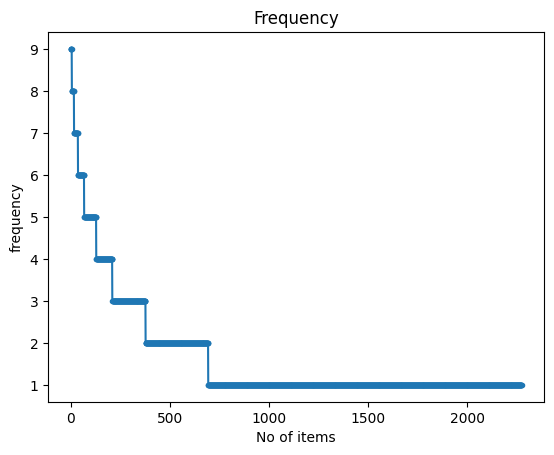

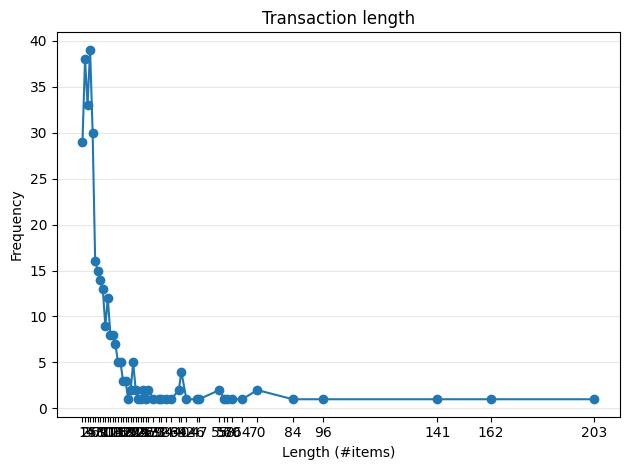

In [109]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_neutral.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 252
Number of items : 1787
Minimum Transaction Size : 1
Average Transaction Size : 12.420634920634921
Maximum Transaction Size : 143
Standard Deviation Transaction Size : 14.390998715909895
Variance in Transaction Sizes : 207.92594700562827
Sparsity : 0.9930494488412788


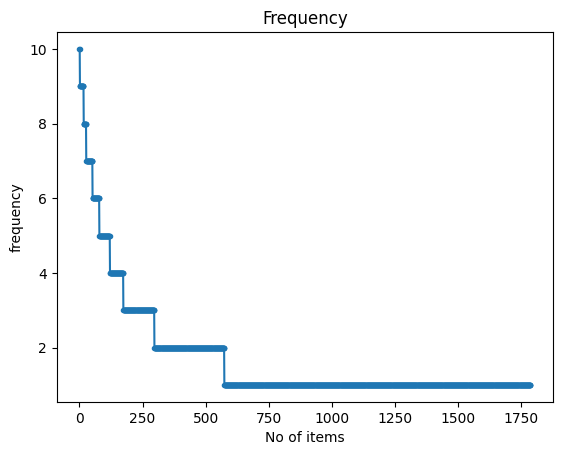

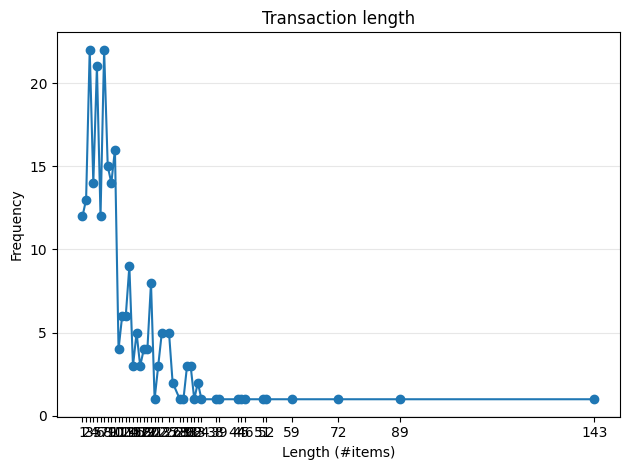

In [110]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_negative.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 86
Number of items : 939
Minimum Transaction Size : 1
Average Transaction Size : 14.94186046511628
Maximum Transaction Size : 94
Standard Deviation Transaction Size : 17.977605352579307
Variance in Transaction Sizes : 326.99658002735976
Sparsity : 0.9840874755430071


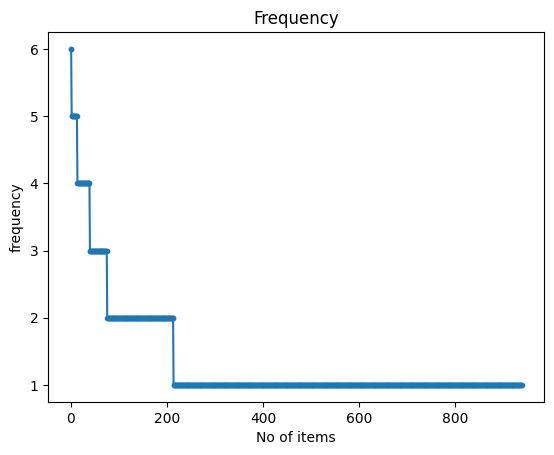

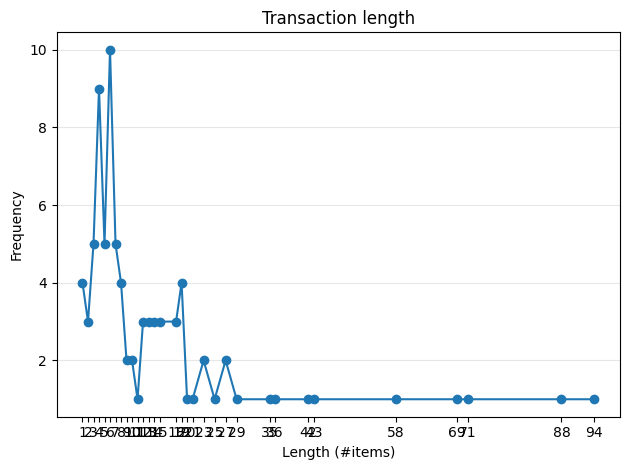

In [111]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_positive.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

### 用FP_Growth演算法，設定最小支持度=4

In [112]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=4
obj1 = alg.FPGrowth(iFile='td_freq_db_neutral.csv', minSup=minSup)
obj1.mine()
frequentPatternsDF_neutral= obj1.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_neutral))) 
print('Runtime: ' + str(obj1.getRuntime()))

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 2272
Runtime: 0.0034580230712890625


In [113]:
obj1.save('freq_patterns_neutral_minSup9.txt') #save the patterns
frequentPatternsDF_neutral

,Patterns,Support
0,25,4
1,buying,4
2,change,4
3,chinese,4
4,come,4
...,...,...
2267,let,9
2268,looking,9
2269,much,9
2270,time,9


In [114]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=4
obj1 = alg.FPGrowth(iFile='td_freq_db_negative.csv', minSup=minSup)
obj1.mine()
frequentPatternsDF_negative= obj1.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_negative))) 
print('Runtime: ' + str(obj1.getRuntime()))

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 176
Runtime: 0.002624034881591797


In [115]:
obj1.save('freq_patterns_negative_minSup9.txt') 
frequentPatternsDF_negative

,Patterns,Support
0,actually,4
1,far,4
2,looking,4
3,many,4
4,treasuries,4
...,...,...
171,should,9
172,these,9
173,good,9
174,still,10


In [116]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=4
obj1 = alg.FPGrowth(iFile='td_freq_db_positive.csv', minSup=minSup)
obj1.mine()
frequentPatternsDF_positive= obj1.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_positive))) 
print('Runtime: ' + str(obj1.getRuntime()))

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 40
Runtime: 0.0007190704345703125


In [117]:
obj1.save('freq_patterns_positive_minSup9.txt') 
frequentPatternsDF_positive

,Patterns,Support
0,going,4
1,also,4
2,potential,4
3,out,4
4,them,4
5,long,4
6,day,4
7,go,4
8,no,4
9,right,4


### 篩選出每個類別的unique patterns

In [118]:
import pandas as pd

#We group together all of the dataframes related to our found patterns
dfs = [frequentPatternsDF_neutral, frequentPatternsDF_negative, frequentPatternsDF_positive]

# Identify patterns that appear in more than one label
# Count how many times each pattern appears across all dataframes
pattern_counts = {}
for df in dfs:
    for pattern in df['Patterns']:
        if pattern not in pattern_counts:
            pattern_counts[pattern] = 1
        else:
            pattern_counts[pattern] += 1

# Filter out patterns that appear in more than one dataframe
unique_patterns = {pattern for pattern, count in pattern_counts.items() if count == 1}
# Calculate the total number of patterns across all categories
total_patterns_count = sum(len(df) for df in dfs)
# Calculate how many patterns were discarded
discarded_patterns_count = total_patterns_count - len(unique_patterns)

# For each category, filter the patterns to keep only the unique ones
filtered_dfs = []
for df in dfs:
    filtered_df = df[df['Patterns'].isin(unique_patterns)]
    filtered_dfs.append(filtered_df)

# Merge the filtered dataframes into a final dataframe
final_pattern_df = pd.concat(filtered_dfs, ignore_index=True)

# Sort by support
final_pattern_df = final_pattern_df.sort_values(by='Support', ascending=False)

# Display the final result
print(final_pattern_df)
# Print the number of discarded patterns
print(f"Number of patterns discarded: {discarded_patterns_count}")

              Patterns  Support
2292              shit        9
2293            should        9
2196            reddit        9
2195              much        9
2194              make        9
...                ...      ...
2225               ass        4
2226               due        4
2227           insider        4
2228  insider\ttrading        4
0                   25        4

[2322 rows x 2 columns]
Number of patterns discarded: 166


In [127]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Convert 'text' column into term-document matrix using CountVectorizer
count_vect = CountVectorizer()
train_df_tdm = count_vect.fit_transform(train_df['text'])  
terms = count_vect.get_feature_names_out() 

# Tokenize the sentences into sets of unique words
train_df['tokenized_text'] = train_df['text'].str.split().apply(set)

# Initialize the pattern matrix
pattern_matrix = pd.DataFrame(0, index=train_df.index, columns=final_pattern_df['Patterns'])

# Iterate over each pattern and check if all words in the pattern are present in the tokenized sentence
for pattern in final_pattern_df['Patterns']:
    pattern_words = set(pattern.split())  # Tokenize pattern into words
    pattern_matrix[pattern] = train_df['tokenized_text'].apply(lambda x: 1 if pattern_words.issubset(x) else 0)

# Convert the term-document matrix to a DataFrame for easy merging
tdm_df = pd.DataFrame(train_df_tdm.toarray(), columns=terms, index=train_df.index)

# Concatenate the original TDM and the pattern matrix to augment the features
augmented_df = pd.concat([tdm_df, pattern_matrix], axis=1)

augmented_df

,00,000,01378,02,027,03,08,10,100,1000,...,media,won,part,insane,making,ass,due,insider,insider\ttrading,25
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
673,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
674,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
675,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### >>> **Exercise 17 :** 

Implement the FAE Top-K and MaxFPGrowth algorithms from the PAMI library to analyze the 'neutral' label in our processed database.

In [130]:
# Answer Here
input_file = "td_freq_db_neutral.csv"
# FAE Top-K
from PAMI.frequentPattern.topk import FAE as fae
k_values = [50, 100, 150]
for k in k_values:
    print(f"[FAE Top-{k}] on neutral ")
    fae_obj = fae.FAE(iFile=input_file, k=k)
    fae_obj.mine()
    fae_df = fae_obj.getPatternsAsDataFrame()
    print('Total No of patterns: ' + str(len(fae_df))) 
    print('Runtime: ' + str(fae_obj.getRuntime()))
    fae_obj.save(f'freq_patterns_neutral_fae{k}.txt') 
    display(fae_df)

[FAE Top-50] on neutral 
 TopK frequent patterns were successfully generated using FAE algorithm.
Total No of patterns: 50
Runtime: 0.007279872894287109


,Patterns,Support
0,make,9
1,let,9
2,looking,9
3,much,9
4,time,9
5,reddit,9
6,after,8
7,say,8
8,tariffs,8
9,thing,8


[FAE Top-100] on neutral 
 TopK frequent patterns were successfully generated using FAE algorithm.
Total No of patterns: 100
Runtime: 0.0035037994384765625


,Patterns,Support
0,make,9
1,let,9
2,looking,9
3,much,9
4,time,9
...,...,...
95,things,5
96,didn,5
97,pretty,5
98,bonds,5


[FAE Top-150] on neutral 
 TopK frequent patterns were successfully generated using FAE algorithm.
Total No of patterns: 150
Runtime: 0.02802586555480957


,Patterns,Support
0,make,9
1,let,9
2,looking,9
3,much,9
4,time,9
...,...,...
145,jasmyusd cryptocurrency coinbase trends highli...,5
146,cryptocurrency coinbase trends highlights cap ...,5
147,cryptocurrency coinbase trends highlights cap ...,5
148,coinbase trends highlights cap pepeusd ethusd ...,5


In [131]:
# Answer Here
# MaxFPGrowth
from PAMI.frequentPattern.maximal import MaxFPGrowth as maxfp
minsups = [3, 4, 6]
for ms in minsups:
    print(f"[MaxFPGrowth] minSup={ms} on neutral ")
    mx_obj = maxfp.MaxFPGrowth(iFile=input_file, minSup=ms)
    mx_obj.mine()
    mx_df = mx_obj.getPatternsAsDataFrame()
    print('Total No of patterns: ' + str(len(mx_df))) 
    print('Runtime: ' + str(mx_obj.getRuntime()))
    display(mx_df)

[MaxFPGrowth] minSup=3 on neutral 
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Total No of patterns: 306
Runtime: 0.02000594139099121


,Patterns,Support
0,done,3
1,lmk,3
2,interesting,3
3,set,3
4,under,3
...,...,...
301,after,8
302,reddit,9
303,much,9
304,make looking,3


[MaxFPGrowth] minSup=4 on neutral 
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Total No of patterns: 188
Runtime: 0.004170894622802734


,Patterns,Support
0,powell,4
1,record,4
2,place,4
3,everything,4
4,lmao,4
...,...,...
183,time,9
184,much,9
185,looking,9
186,let,9


[MaxFPGrowth] minSup=6 on neutral 
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Total No of patterns: 66
Runtime: 0.0017802715301513672


,Patterns,Support
0,before,6
1,talk,6
2,without,6
3,made,6
4,usd,6
...,...,...
61,time,9
62,much,9
63,looking,9
64,let,9


### differences and similarities in the outputs and performance

In [132]:
'''
1. FPGrowth  
- A complete frequent pattern mining method that produces the largest number of outputs (2,322 patterns).  
- The results contain many low-level and short word patterns, which are informative but highly redundant.  
- Extremely fast (only 0.003 seconds), but less suitable for later interpretation or model training.  

2. FAE Top-K  
- Allows direct control over the output size.  
- Results for Top-50 to Top-150 show that the highest-ranked words match those with high support in FPGrowth.  
- Runtime increases as the K value grows.  

3. MaxFPGrowth  
- Outputs only maximal patterns, which are the largest combinations that cannot be further expanded.  
- Produces fewer patterns than FPGrowth, but each pattern has a longer structure and richer semantic meaning.  
'''

'\n1. FPGrowth  \n- A complete frequent pattern mining method that produces the largest number of outputs (2,322 patterns).  \n- The results contain many low-level and short word patterns, which are informative but highly redundant.  \n- Extremely fast (only 0.003 seconds), but less suitable for later interpretation or model training.  \n\n2. FAE Top-K  \n- Allows direct control over the output size.  \n- Results for Top-50 to Top-150 show that the highest-ranked words match those with high support in FPGrowth.  \n- Runtime increases as the K value grows.  \n\n3. MaxFPGrowth  \n- Outputs only maximal patterns, which are the largest combinations that cannot be further expanded.  \n- Produces fewer patterns than FPGrowth, but each pattern has a longer structure and richer semantic meaning.  \n'

### 4.6 Dimensionality Reduction


In [133]:
#Applying dimensionality reduction with only the document-term frequency data
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

#This might take a couple of minutes to execute
# Apply PCA, t-SNE, and UMAP to the data
X_pca_tdm = PCA(n_components=2).fit_transform(tdm_df.values)
X_tsne_tdm = TSNE(n_components=2).fit_transform(tdm_df.values)
X_umap_tdm = umap.UMAP(n_components=2).fit_transform(tdm_df.values)

In [134]:
X_pca_tdm.shape

(677, 2)

In [135]:
X_tsne_tdm.shape

(677, 2)

In [136]:
X_umap_tdm.shape

(677, 2)

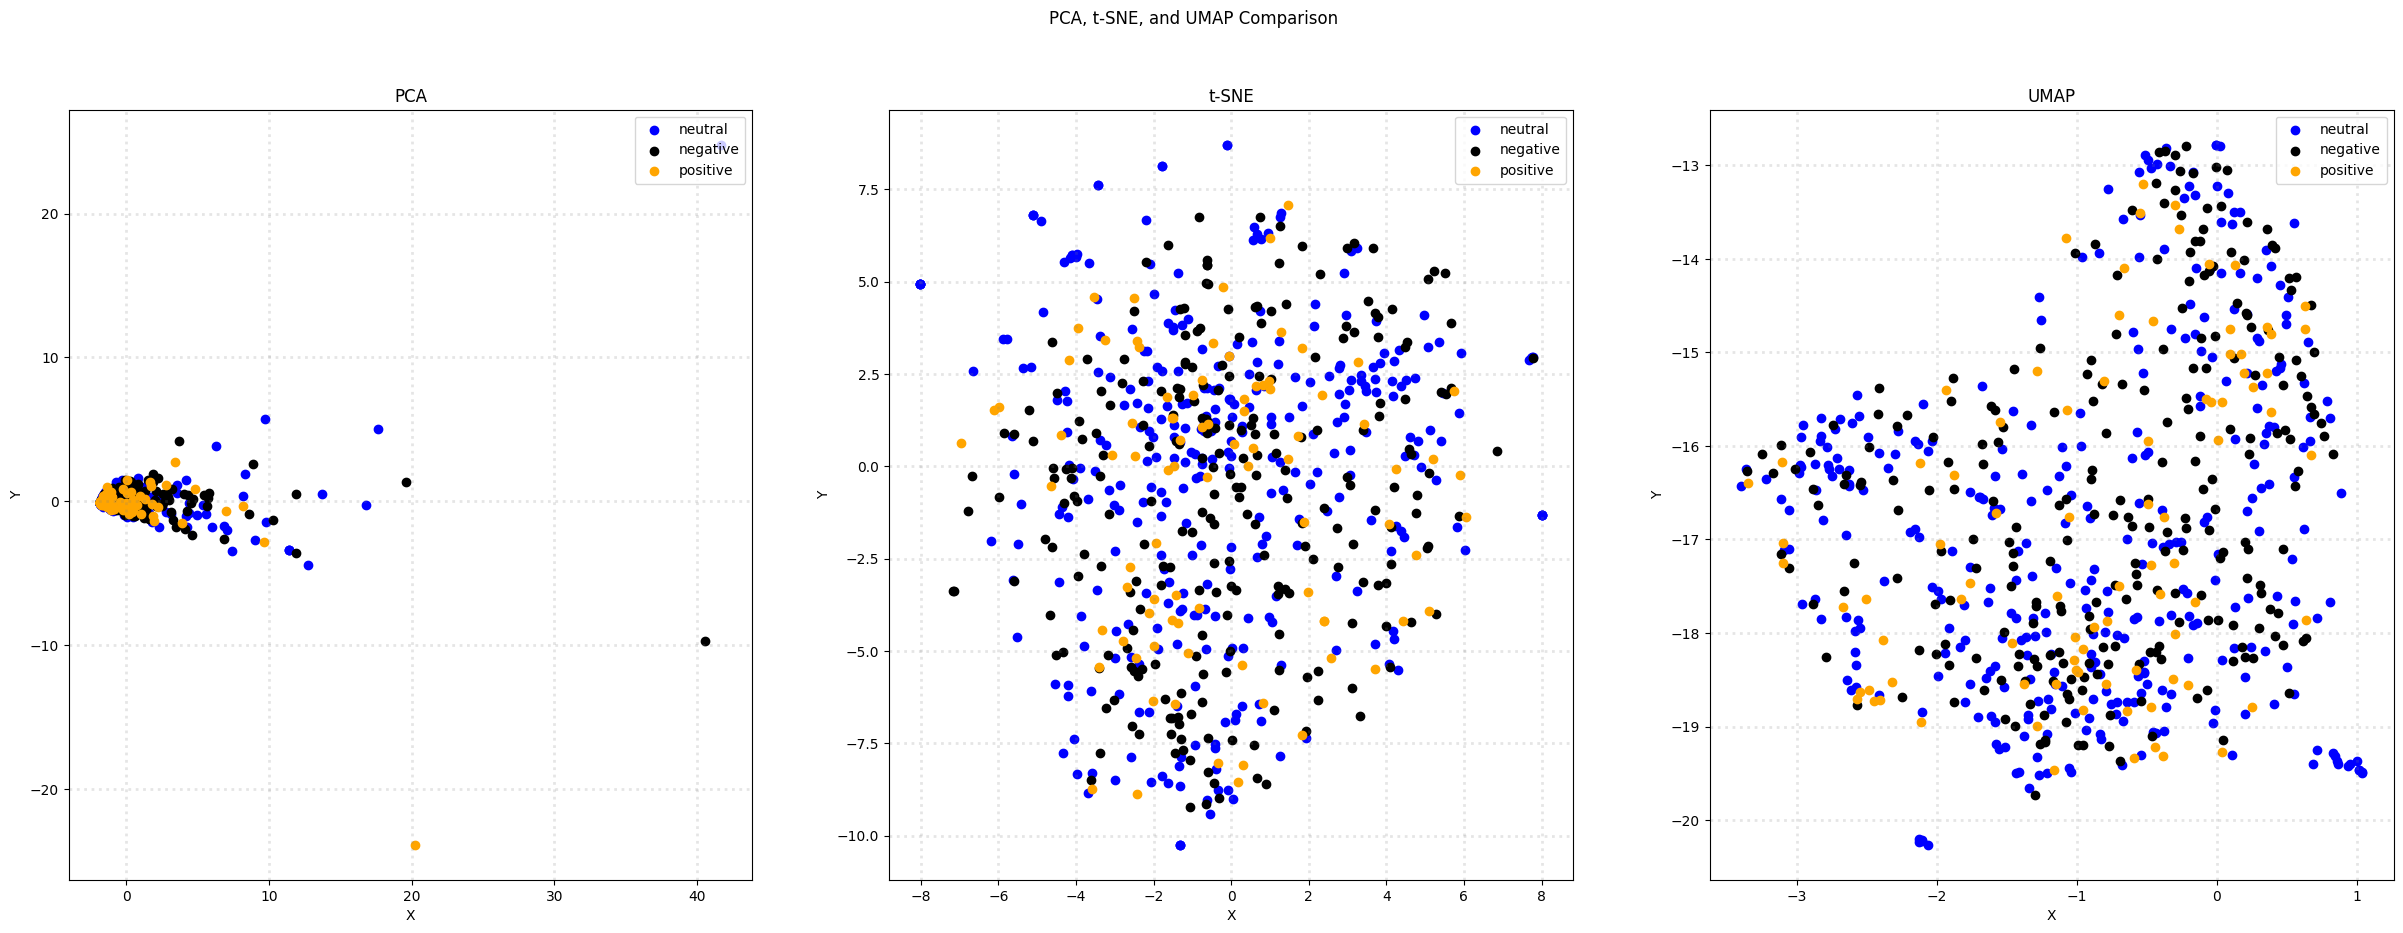

In [137]:
# Plot the results in subplots
col = [ 'blue', 'black', 'orange']
labels = train_df['label_name'].unique() 

fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Create 3 subplots for PCA, t-SNE, and UMAP
fig.suptitle('PCA, t-SNE, and UMAP Comparison')

# Define a function to create a scatter plot for each method
def plot_scatter(ax, train_df_reduced, title):
    for c, label in zip(col, labels):
        xs = train_df_reduced[train_df['label_name'] == label].T[0]
        ys = train_df_reduced[train_df['label_name'] == label].T[1]
        ax.scatter(xs, ys, c=c, marker='o', label=label)
    
    ax.grid(color='gray', linestyle=':', linewidth=2, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')

# Step 4: Create scatter plots for PCA, t-SNE, and UMAP
plot_scatter(axes[0], X_pca_tdm, 'PCA')
plot_scatter(axes[1], X_tsne_tdm, 't-SNE')
plot_scatter(axes[2], X_umap_tdm, 'UMAP')

plt.show()

In [138]:
#This might take a couple of minutes to execute
#Applying dimensionality reduction with both the document-term frequency data and the pattern derived data
# Apply PCA, t-SNE, and UMAP to the data
X_pca_aug = PCA(n_components=2).fit_transform(augmented_df.values)
X_tsne_aug = TSNE(n_components=2).fit_transform(augmented_df.values)
X_umap_aug = umap.UMAP(n_components=2).fit_transform(augmented_df.values)

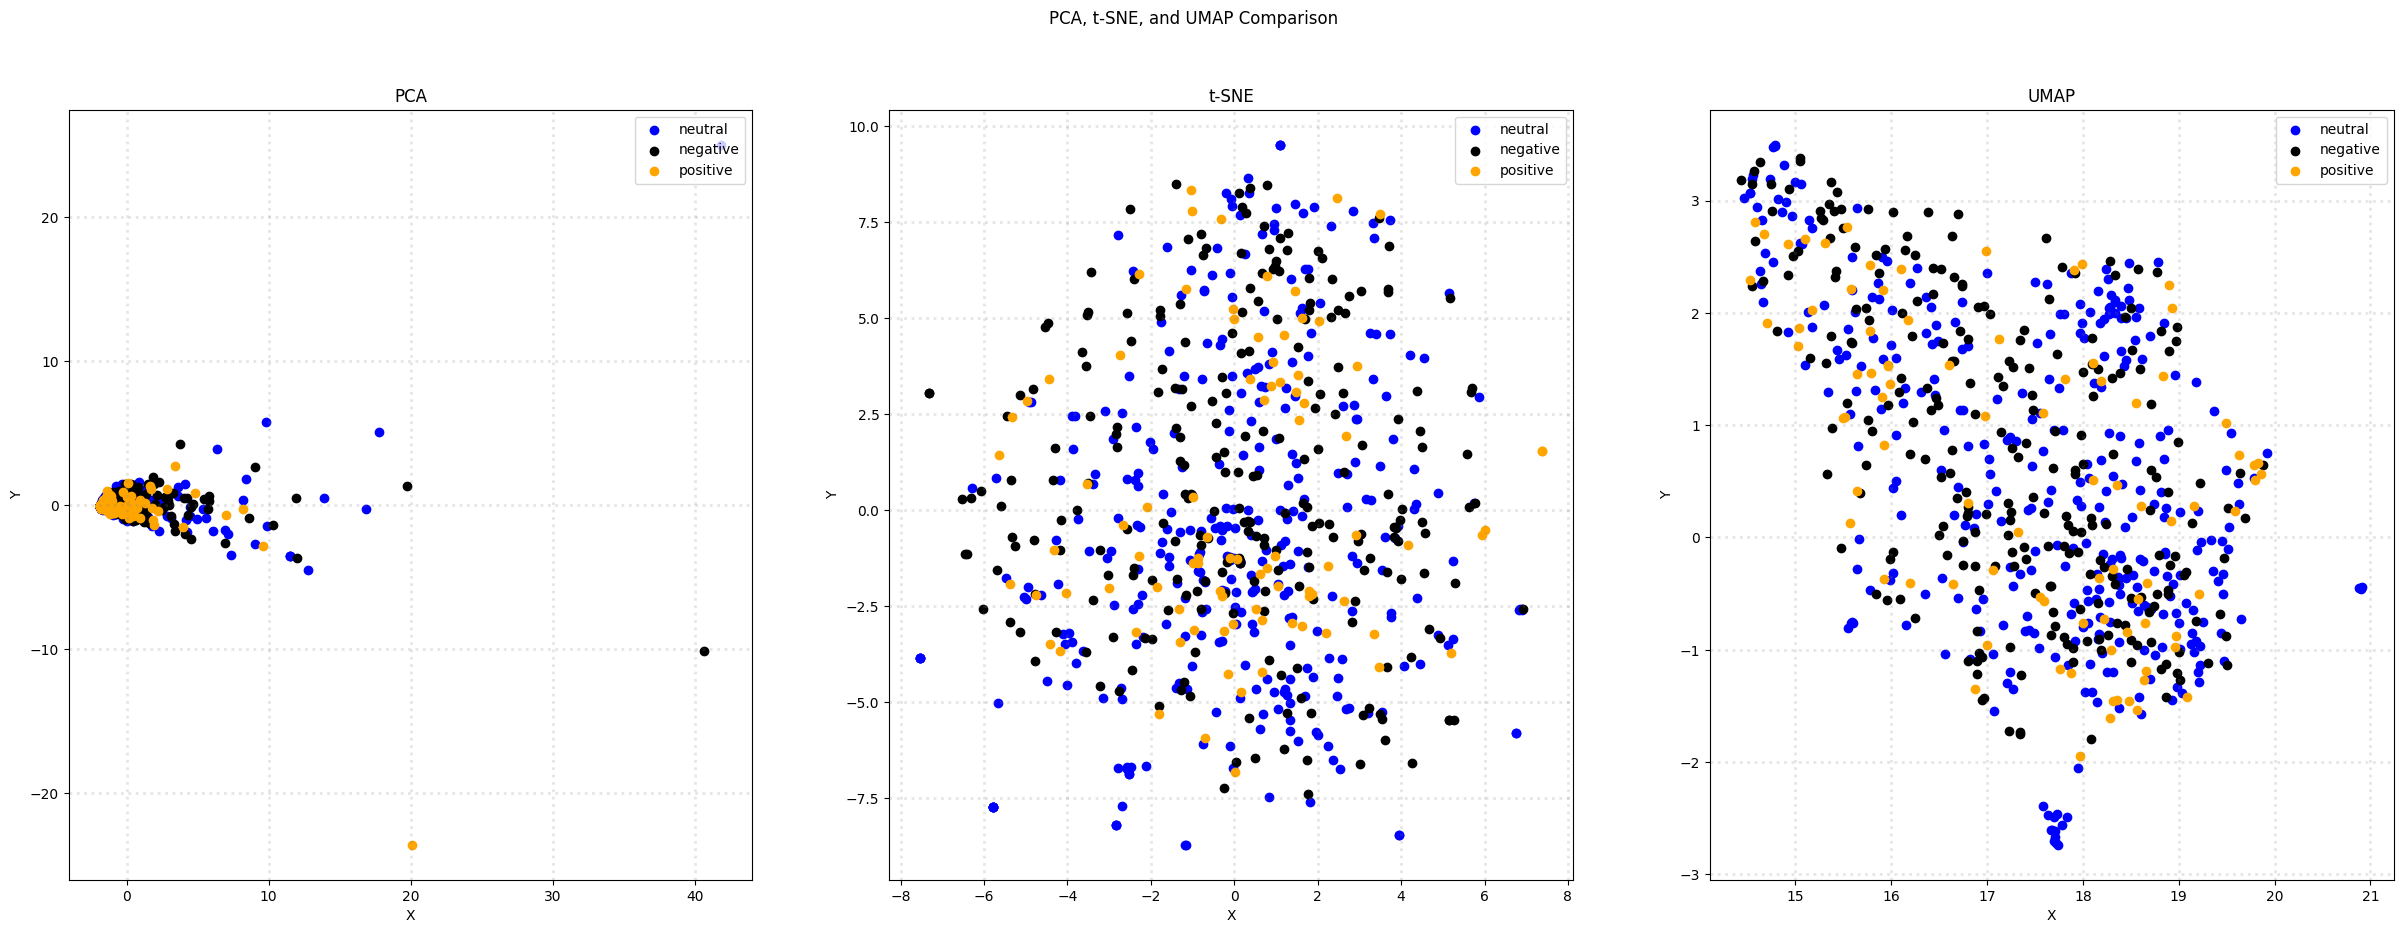

In [139]:
# Plot the results in subplots
col = ['blue', 'black', 'orange']
labels = train_df['label_name'].unique() 

fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Create 3 subplots for PCA, t-SNE, and UMAP
fig.suptitle('PCA, t-SNE, and UMAP Comparison')

# Define a function to create a scatter plot for each method
def plot_scatter(ax, train_df_reduced, title):
    for c, label in zip(col, labels):
        xs = train_df_reduced[train_df['label_name'] == label].T[0]
        ys = train_df_reduced[train_df['label_name'] == label].T[1]
        ax.scatter(xs, ys, c=c, marker='o', label=label)
    
    ax.grid(color='gray', linestyle=':', linewidth=2, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')

# Create scatter plots for PCA, t-SNE, and UMAP
plot_scatter(axes[0], X_pca_aug, 'PCA')
plot_scatter(axes[1], X_tsne_aug, 't-SNE')
plot_scatter(axes[2], X_umap_aug, 'UMAP')

plt.show()

### >>> Exercise 18 :
reduce the dimension to 3, and plot the result use 3-D plot. Use at least 3 different angle (camera position) to check your result and describe what you found.

In [ ]:
#Answer Here
#reduce the dimension to 3,using augmented_df
X_pca_3d = PCA(n_components=3).fit_transform(augmented_df.values)
X_tsne_3d = TSNE(n_components=3).fit_transform(augmented_df.values)
X_umap_3d = umap.UMAP(n_components=3).fit_transform(augmented_df.values)

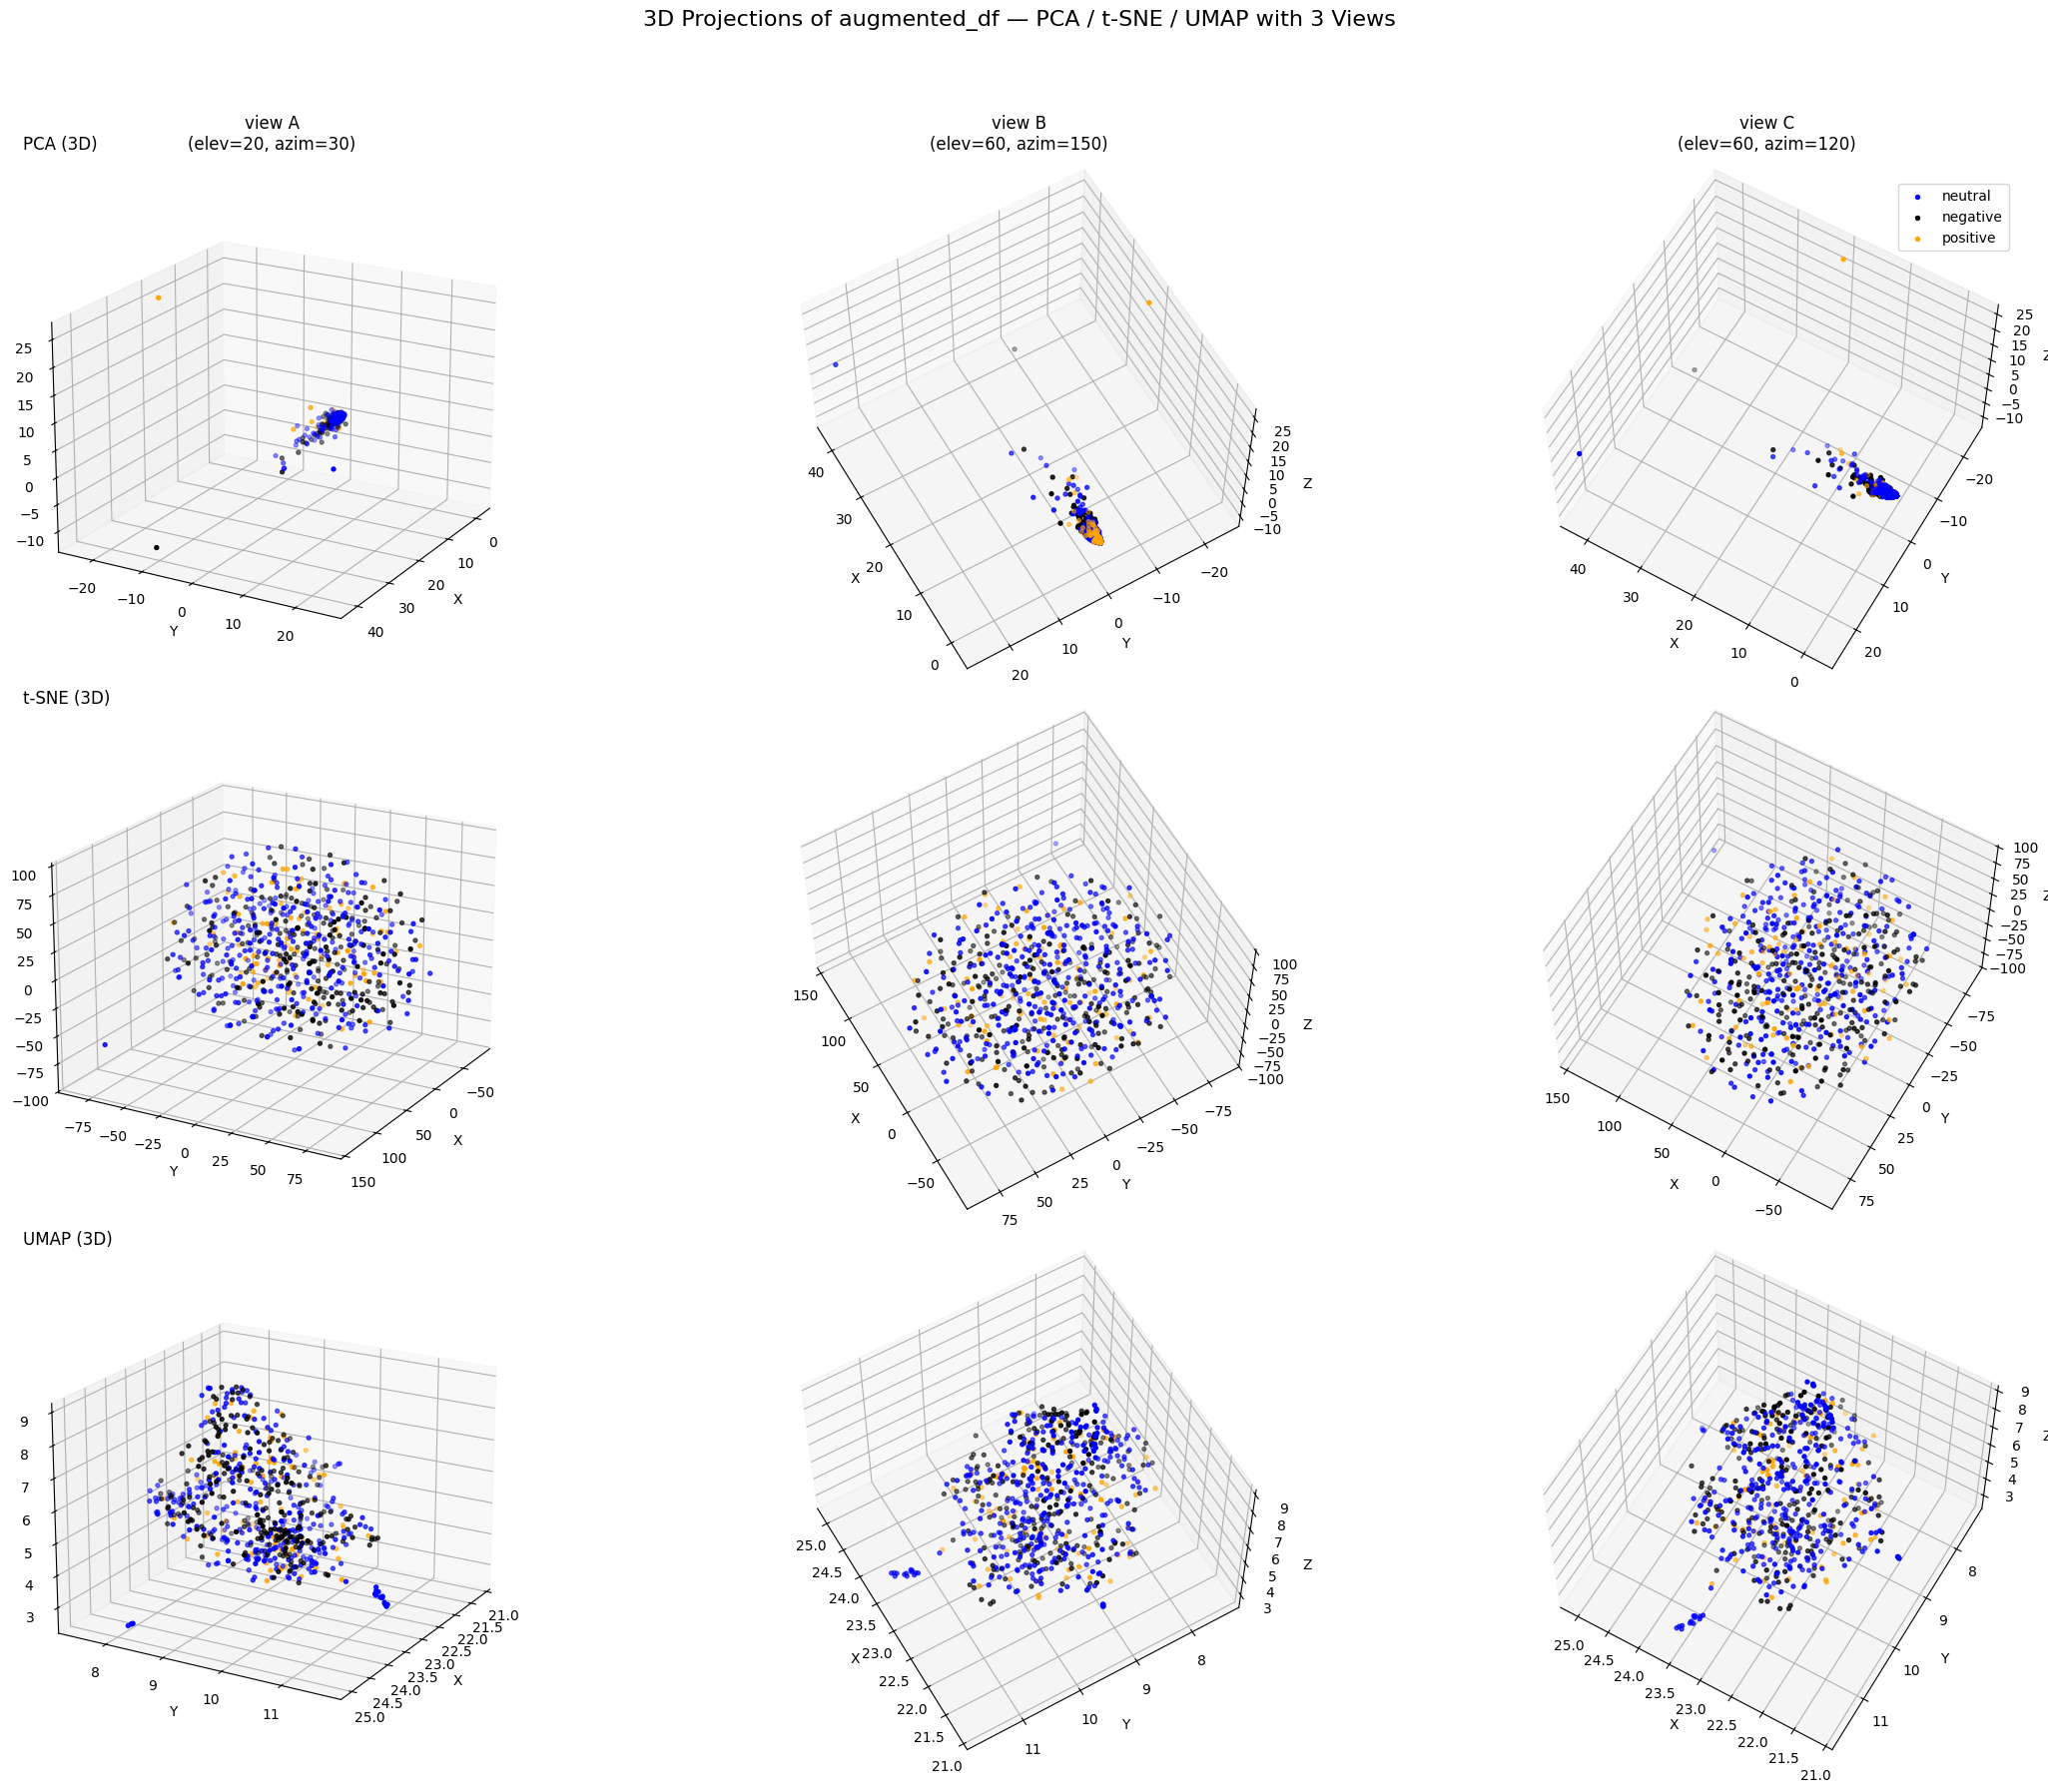

In [141]:
col = ['blue', 'black', 'orange']
labels = train_df['label_name'].unique()
views = [("view A",20, 30), ("view B",60, 150),("view C",60, 120)]
algos = [("PCA (3D)",  X_pca_3d),("t-SNE (3D)", X_tsne_3d),("UMAP (3D)", X_umap_3d),]

fig = plt.figure(figsize=(24, 18))
fig.suptitle('3D Projections of augmented_df — PCA / t-SNE / UMAP with 3 Views', fontsize=16)

def plot_scatter_3d(ax, X_reduced, elev, azim, show_legend=False):
    for c, label in zip(col, labels):
        mask = (train_df['label_name'] == label)
        xs = X_reduced[mask, 0]
        ys = X_reduced[mask, 1]
        zs = X_reduced[mask, 2]
        ax.scatter(xs, ys, zs, c=c, marker='o', s=8, label=label)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=elev, azim=azim)
    ax.grid(True, linestyle=':', alpha=0.2)
    if show_legend:
        ax.legend(loc='upper right')

for r, (algo_name, algo) in enumerate(algos):
    for c_idx, (vlabel, elev, azim) in enumerate(views):
        ax = fig.add_subplot(3, 3, r*3 + c_idx + 1, projection='3d')
        show_leg = (r == 0 and c_idx == 2)
        plot_scatter_3d(ax, algo, elev, azim, show_legend=show_leg)
        if c_idx == 0:
            ax.set_title(algo_name, loc='left', pad=10, fontsize=12)
        if r == 0:
            ax.set_title(f"{vlabel}\n(elev={elev}, azim={azim})", pad=20, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
'''
The three dimensionality reduction results show a high degree of overlap and semantic intersection among the categories, 
indicating that positive, negative, and neutral texts share many common lexical features.
'''

### 4.7 Discretization and Binarization


In [142]:
from sklearn import preprocessing, metrics, decomposition, pipeline, dummy

In [143]:
mlb = preprocessing.LabelBinarizer()

In [144]:
mlb.fit(train_df.label)

,neg_label,0
,pos_label,1
,sparse_output,False


In [145]:
train_df['bin_label'] = mlb.transform(train_df['label']).tolist()

In [146]:
train_df[0:9]

,text,label,label_name,unigrams,tokenized_text,bin_label
0,Disgusting tactics,0.0,neutral,"[Disgusting, tactics]","{Disgusting, tactics}","[0, 1, 0]"
1,Cope harder,-1.0,negative,"[Cope, harder]","{Cope, harder}","[1, 0, 0]"
2,# Stock winners\n\n\n\n**11.65% GameStop**\n\n...,0.0,neutral,"[#, Stock, winners, *, *, 11.65, %, GameStop, ...","{want, next, your, programs.**, scoop, GameSto...","[0, 1, 0]"
3,DOGE is going up today 153%,1.0,positive,"[DOGE, is, going, up, today, 153, %]","{is, DOGE, going, 153%, today, up}","[0, 0, 1]"
4,So they went from saying redditors are bad for...,1.0,positive,"[So, they, went, from, saying, redditors, are,...","{from, are, redditors, bad, So, manipulating, ...","[0, 0, 1]"
5,I think we are past the numbers. Just assume f...,-1.0,negative,"[I, think, we, are, past, the, numbers, ., Jus...","{now, could, another, the, That, We, is, alrea...","[1, 0, 0]"
6,it was amc day today. fsr after hrs,0.0,neutral,"[it, was, amc, day, today, ., fsr, after, hrs]","{day, it, hrs, after, fsr, today., amc, was}","[0, 1, 0]"
7,Trump grossly miscalculated if he thought he c...,-1.0,negative,"[Trump, grossly, miscalculated, if, he, though...","{weak,, could, the, when, lot, is, any, again,...","[1, 0, 0]"
8,It's basically just bickering with math at thi...,-1.0,negative,"[It, 's, basically, just, bickering, with, mat...","{that, stuff., each, It's, pretty, ensure, jus...","[1, 0, 0]"


### >>> **Exercise 19 :**
Try to generate the binarization using the `label_name` column instead. Does it work?

In [148]:
# Answer here
mlb.fit(train_df.label_name)
train_df['bin_label_name'] = mlb.transform(train_df['label_name']).tolist()
train_df[0:9]

,text,label,label_name,unigrams,tokenized_text,bin_label,bin_label_name
0,Disgusting tactics,0.0,neutral,"[Disgusting, tactics]","{Disgusting, tactics}","[0, 1, 0]","[0, 1, 0]"
1,Cope harder,-1.0,negative,"[Cope, harder]","{Cope, harder}","[1, 0, 0]","[1, 0, 0]"
2,# Stock winners\n\n\n\n**11.65% GameStop**\n\n...,0.0,neutral,"[#, Stock, winners, *, *, 11.65, %, GameStop, ...","{want, next, your, programs.**, scoop, GameSto...","[0, 1, 0]","[0, 1, 0]"
3,DOGE is going up today 153%,1.0,positive,"[DOGE, is, going, up, today, 153, %]","{is, DOGE, going, 153%, today, up}","[0, 0, 1]","[0, 0, 1]"
4,So they went from saying redditors are bad for...,1.0,positive,"[So, they, went, from, saying, redditors, are,...","{from, are, redditors, bad, So, manipulating, ...","[0, 0, 1]","[0, 0, 1]"
5,I think we are past the numbers. Just assume f...,-1.0,negative,"[I, think, we, are, past, the, numbers, ., Jus...","{now, could, another, the, That, We, is, alrea...","[1, 0, 0]","[1, 0, 0]"
6,it was amc day today. fsr after hrs,0.0,neutral,"[it, was, amc, day, today, ., fsr, after, hrs]","{day, it, hrs, after, fsr, today., amc, was}","[0, 1, 0]","[0, 1, 0]"
7,Trump grossly miscalculated if he thought he c...,-1.0,negative,"[Trump, grossly, miscalculated, if, he, though...","{weak,, could, the, when, lot, is, any, again,...","[1, 0, 0]","[1, 0, 0]"
8,It's basically just bickering with math at thi...,-1.0,negative,"[It, 's, basically, just, bickering, with, mat...","{that, stuff., each, It's, pretty, ensure, jus...","[1, 0, 0]","[1, 0, 0]"


# 5. Data Exploration

In [152]:
# We retrieve 3 sentences for a random record
document_to_transform_1 = []
random_record_1 = train_df.iloc[10]
random_record_1 = random_record_1['text']
document_to_transform_1.append(random_record_1)

document_to_transform_2 = []
random_record_2 = train_df.iloc[100]
random_record_2 = random_record_2['text']
document_to_transform_2.append(random_record_2)

document_to_transform_3 = []
random_record_3 = train_df.iloc[500]
random_record_3 = random_record_3['text']
document_to_transform_3.append(random_record_3)

In [157]:
print(document_to_transform_1)
print(document_to_transform_2)
print(document_to_transform_3)
print(train_df['label_name'].iloc[10])
print(train_df['label_name'].iloc[100])
print(train_df['label_name'].iloc[500])

['Emoluments clause? lol. What is that?']
['Agolf Shittler or tangerine toddler.']
['Trump is delusional and so as his supporters. So yeah, most likely.']
neutral
negative
negative


In [155]:
from sklearn.preprocessing import binarize

# Transform sentence with Vectorizers
document_vector_count_1 = count_vect.transform(document_to_transform_1)
document_vector_count_2 = count_vect.transform(document_to_transform_2)
document_vector_count_3 = count_vect.transform(document_to_transform_3)

# Binarize vectors to simplify: 0 for abscence, 1 for prescence
document_vector_count_1_bin = binarize(document_vector_count_1)
document_vector_count_2_bin = binarize(document_vector_count_2)
document_vector_count_3_bin = binarize(document_vector_count_3)

# print vectors
print("Let's take a look at the count vectors:")
print(document_vector_count_1.todense())
print(document_vector_count_2.todense())
print(document_vector_count_3.todense())

Let's take a look at the count vectors:
[[0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]]


In [156]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate Cosine Similarity
cos_sim_count_1_2 = cosine_similarity(document_vector_count_1, document_vector_count_2, dense_output=True)
cos_sim_count_1_3 = cosine_similarity(document_vector_count_1, document_vector_count_3, dense_output=True)
cos_sim_count_2_3 = cosine_similarity(document_vector_count_2, document_vector_count_3, dense_output=True)

cos_sim_count_1_1 = cosine_similarity(document_vector_count_1, document_vector_count_1, dense_output=True)
cos_sim_count_2_2 = cosine_similarity(document_vector_count_2, document_vector_count_2, dense_output=True)
cos_sim_count_3_3 = cosine_similarity(document_vector_count_3, document_vector_count_3, dense_output=True)

# Print 
print("Cosine Similarity using count bw 1 and 2: %(x)f" %{"x":cos_sim_count_1_2})
print("Cosine Similarity using count bw 1 and 3: %(x)f" %{"x":cos_sim_count_1_3})
print("Cosine Similarity using count bw 2 and 3: %(x)f" %{"x":cos_sim_count_2_3})

print("Cosine Similarity using count bw 1 and 1: %(x)f" %{"x":cos_sim_count_1_1})
print("Cosine Similarity using count bw 2 and 2: %(x)f" %{"x":cos_sim_count_2_2})
print("Cosine Similarity using count bw 3 and 3: %(x)f" %{"x":cos_sim_count_3_3})

Cosine Similarity using count bw 1 and 2: 0.000000
Cosine Similarity using count bw 1 and 3: 0.109109
Cosine Similarity using count bw 2 and 3: 0.000000
Cosine Similarity using count bw 1 and 1: 1.000000
Cosine Similarity using count bw 2 and 2: 1.000000
Cosine Similarity using count bw 3 and 3: 1.000000


/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/452772485.py:13: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/452772485.py:14: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/452772485.py:15: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/452772485.py:17: Dep

### >>> Exercise 20 (take home):
changing the texts reference for Text 1, Text 2, and Text 3. What do you observe from the Cosine Similarity results of different text references? following the modifications to texts reference, how can the results of the cosine similarity be interpreted?

In [159]:
document_to_transform_1 = []
random_record_1 = train_df.iloc[5]
random_record_1 = random_record_1['text']
document_to_transform_1.append(random_record_1)

document_to_transform_2 = []
random_record_2 = train_df.iloc[55]
random_record_2 = random_record_2['text']
document_to_transform_2.append(random_record_2)

document_to_transform_3 = []
random_record_3 = train_df.iloc[555]
random_record_3 = random_record_3['text']
document_to_transform_3.append(random_record_3)

print(document_to_transform_1)
print(document_to_transform_2)
print(document_to_transform_3)
print(train_df['label_name'].iloc[5])
print(train_df['label_name'].iloc[55])
print(train_df['label_name'].iloc[555])

# Transform sentence with Vectorizers
document_vector_count_1 = count_vect.transform(document_to_transform_1)
document_vector_count_2 = count_vect.transform(document_to_transform_2)
document_vector_count_3 = count_vect.transform(document_to_transform_3)

# Binarize vectors to simplify: 0 for abscence, 1 for prescence
document_vector_count_1_bin = binarize(document_vector_count_1)
document_vector_count_2_bin = binarize(document_vector_count_2)
document_vector_count_3_bin = binarize(document_vector_count_3)

# print vectors
print("Let's take a look at the count vectors:")
print(document_vector_count_1.todense())
print(document_vector_count_2.todense())
print(document_vector_count_3.todense())

# Calculate Cosine Similarity
cos_sim_count_1_2 = cosine_similarity(document_vector_count_1, document_vector_count_2, dense_output=True)
cos_sim_count_1_3 = cosine_similarity(document_vector_count_1, document_vector_count_3, dense_output=True)
cos_sim_count_2_3 = cosine_similarity(document_vector_count_2, document_vector_count_3, dense_output=True)

cos_sim_count_1_1 = cosine_similarity(document_vector_count_1, document_vector_count_1, dense_output=True)
cos_sim_count_2_2 = cosine_similarity(document_vector_count_2, document_vector_count_2, dense_output=True)
cos_sim_count_3_3 = cosine_similarity(document_vector_count_3, document_vector_count_3, dense_output=True)

# Print 
print("Cosine Similarity using count bw 1 and 2: %(x)f" %{"x":cos_sim_count_1_2})
print("Cosine Similarity using count bw 1 and 3: %(x)f" %{"x":cos_sim_count_1_3})
print("Cosine Similarity using count bw 2 and 3: %(x)f" %{"x":cos_sim_count_2_3})

print("Cosine Similarity using count bw 1 and 1: %(x)f" %{"x":cos_sim_count_1_1})
print("Cosine Similarity using count bw 2 and 2: %(x)f" %{"x":cos_sim_count_2_2})
print("Cosine Similarity using count bw 3 and 3: %(x)f" %{"x":cos_sim_count_3_3})

['I think we are past the numbers. Just assume folks world wide are now looking for another safe place to store their money.\n\nWe used to be the place. That is over.\n\nHell I am in the US and I am looking for a safer place to store my money.\n\nWe are in uncharted waters here and we have an economy that was already shaky to begin with.\n\nFar too many Americans are woefully unaware of how big the world is or how much we actually depend on them. \n\nLots of hard lessons to be learned going forward.\n\nTo sell bonds and treasuries we need people to believe their money is safe if they buy them. That idea is rapidly exiting stage right.\n\nI could be wrong but I think those rates are  screaming at us that we are going down rapidly as a trusted partner.']
['no state and local taxes']
["Etrade has a feed of news articles about how reddit is dumping GME for silver, and actual-reddit is just looking at their .\n\nAin't no paper-silver-hands around here. Diamonds are forever, bb."]
negative
n

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/3411225142.py:49: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/3411225142.py:50: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/3411225142.py:51: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/var/folders/lx/b868nzys5b9139jlvjxp7r800000gn/T/ipykernel_18843/3411225142.py:53:

In [ ]:
'''
The overall Cosine similarity among the three texts is relatively low, indicating that they share few overlapping words at the lexical level.
Text 2 is very short (only “no state and local taxes”), which means it contains very few usable words, resulting in particularly low similarity with the other texts. 
Because short texts produce highly sparse feature vectors—mostly filled with zeros—their vector directions are almost impossible to align with those of longer texts.
'''

# 6. Data Classification


In [201]:
#Model with only the document-term frequency data
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Create a mapping from numerical labels to label names
label_mapping = dict(train_df[['label', 'label_name']].drop_duplicates().values)

# Convert the numerical label labels to text labels
target_names = [label_mapping[label] for label in sorted(label_mapping.keys())]

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(tdm_df, train_df['label'], test_size=0.3, random_state=42, stratify=train_df['label'])

In [202]:
X_train

,00,000,01378,02,027,03,08,10,100,1000,...,your,yours,yourself,yourselves,yoyo,yup,zero,zgld,zone,zsil
106,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
426,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
60,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
314,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
376,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
411,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [203]:
# Train the Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test)

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

Accuracy: 0.5833333333333334

Classification Report:
               precision    recall  f1-score   support

    negative     0.5732    0.6184    0.5949        76
     neutral     0.6087    0.6863    0.6452       102
    positive     0.2857    0.0769    0.1212        26

    accuracy                         0.5833       204
   macro avg     0.4892    0.4605    0.4538       204
weighted avg     0.5543    0.5833    0.5597       204



### >>> **Exercise 21 :**
Use the augmented data to perform classification using Naive Bayes as in the previous steps.

In [218]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(augmented_df, train_df['label'], test_size=0.3, random_state=42, stratify=train_df['label'])
print(X_train_a)
print(X_test_a)

nb_classifier.fit(X_train_a, y_train_a)

y_pred_a = nb_classifier.predict(X_test_a)

print("Accuracy:", accuracy_score(y_test_a, y_pred_a))
print("\nClassification Report:\n", classification_report(y_test_a, y_pred_a, target_names=target_names, digits=4))

     000   10  100   11   12   13   15  150  17th  18630  ...  media  won  \
106  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   
426  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   
60   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   
314  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   
20   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   
..   ...  ...  ...  ...  ...  ...  ...  ...   ...    ...  ...    ...  ...   
427  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   
254  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   
376  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   
411  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   
179  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    0.0  ...      0    0   

     part  insane  making  ass  due  insider  insider\ttrading  25  
106   

/Users/kuojouhsiang/Documents/DM2025Labs./DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/kuojouhsiang/Documents/DM2025Labs./DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/kuojouhsiang/Documents/DM2025Labs./DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



### >>> **Exercise 22 :**
What differences can be observed between the results obtained using the original TDM and those obtained using the augmented TDM?

In [205]:
#Answer
'''
After adding the pattern features, the accuracy increased by about 0.1%, indicating that the features extracted through frequent pattern mining 
successfully complemented the structural semantics and co-occurrence information that the pure term-frequency matrix could not capture.
'''

'\nAfter adding the pattern features, the accuracy increased by about 0.1%, indicating that the features extracted through frequent pattern mining \nsuccessfully complemented the structural semantics and co-occurrence information that the pure term-frequency matrix could not capture.\n'

### Decision Tree Classifier

In [206]:
# Decision Tree with only the document-term frequency data
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split the data (already done above, but shown here for clarity)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(tdm_df, train_df['label'], test_size=0.3, random_state=42, stratify=train_df['label'])

# Train Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_dt, y_train_dt)

# Predict and evaluate
y_pred_dt = dt_classifier.predict(X_test_dt)
print("Decision Tree Accuracy (TDM):", accuracy_score(y_test_dt, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test_dt, y_pred_dt, target_names=target_names, digits=4))

Decision Tree Accuracy (TDM): 0.5441176470588235

Classification Report:
               precision    recall  f1-score   support

    negative     0.5400    0.3553    0.4286        76
     neutral     0.5940    0.7745    0.6723       102
    positive     0.2381    0.1923    0.2128        26

    accuracy                         0.5441       204
   macro avg     0.4574    0.4407    0.4379       204
weighted avg     0.5285    0.5441    0.5230       204



### >>> **Exercise 23 :**
Why do you think the performance of Decision Trees is lower than that of Naive Bayes? Provide possible reasons.

In [207]:
#Answer
'''
The large number of features in the text causes the Decision Tree to search across many dimensions to find the best splitting feature, 
which makes it easily affected by random noise and prone to overfitting or unstable branching.
In contrast, Naive Bayes evaluates the overall word distribution and weighting probabilistically, allowing it to capture the global semantic characteristics of each class more effectively.
'''

'\nThe large number of features in the text causes the Decision Tree to search across many dimensions to find the best splitting feature, \nwhich makes it easily affected by random noise and prone to overfitting or unstable branching.\nIn contrast, Naive Bayes evaluates the overall word distribution and weighting probabilistically, allowing it to capture the global semantic characteristics of each class more effectively.\n'

### >>> **Exercise 24 :**
Implement using the augmented data, does the performance improve compared to that obtained with the original TDM? Is it better than Naive Bayes? Provide possible explanations for your observations.

In [208]:
#Answer
X_train_dta, X_test_dta, y_train_dta, y_test_dta = train_test_split(augmented_df, train_df['label'], test_size=0.3, random_state=42, stratify=train_df['label'])

# Train Decision Tree
dt_classifier.fit(X_train_dta, y_train_dta)

# Predict and evaluate
y_pred_a_dt = dt_classifier.predict(X_test_dta)
print("Decision Tree Accuracy (TDM):", accuracy_score(y_test_dta, y_pred_a_dt))
print("\nClassification Report:\n", classification_report(y_test_dta, y_pred_a_dt, target_names=target_names, digits=4))

Decision Tree Accuracy (TDM): 0.5784313725490197

Classification Report:
               precision    recall  f1-score   support

    negative     0.6087    0.3684    0.4590        76
     neutral     0.6014    0.8137    0.6917       102
    positive     0.3500    0.2692    0.3043        26

    accuracy                         0.5784       204
   macro avg     0.5200    0.4838    0.4850       204
weighted avg     0.5721    0.5784    0.5556       204



In [209]:
# observation
'''
Using the augmented data tends to yield slight improvements over the original TDM for Decision Trees, thanks to the additional co-occurrence signals.
Naive Bayes still performed better than the desicion tree using augmented data, because it typically remains stronger for high-dimensional, 
sparse text data, as its probabilistic modeling better captures global word-distribution patterns and is less prone to overfitting than a single Decision Tree.
'''

'\nUsing the augmented data tends to yield slight improvements over the original TDM for Decision Trees, thanks to the additional co-occurrence signals.\nNaive Bayes still performed better than the desicion tree using augmented data, because it typically remains stronger for high-dimensional, \nsparse text data, as its probabilistic modeling better captures global word-distribution patterns and is less prone to overfitting than a single Decision Tree.\n'

### >>> **Exercise 25 :**

In your opinion, how should one choose the best model for a given task, such as the classification example above?

In [210]:
#Answer
'''
Choosing the best model depends on several factors, including the nature of the data, the assumptions of the algorithm, and the intended application.
In general, the best model should be chosen through both theoretical understanding and empirical evaluation — comparing accuracy, computational cost, and interpretability under the given task constraints.
'''

'\nChoosing the best model depends on several factors, including the nature of the data, the assumptions of the algorithm, and the intended application.\nIn general, the best model should be chosen through both theoretical understanding and empirical evaluation — comparing accuracy, computational cost, and interpretability under the given task constraints.\n'

---
## The answer of the third part

# 7.TF-TDF


Build Model

In [211]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(stop_words='english',min_df=2, max_df=0.9,sublinear_tf=True,norm='l2')
X_tfidf = tfidf_vect.fit_transform(train_df['text'])
words = tfidf_vect.get_feature_names_out()
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=words)


In [212]:
tfidf_df

,000,10,100,11,12,13,15,150,17th,18630,...,years,yes,yesterday,yield,yields,yippee,yo,young,yup,zero
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.092664,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
673,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
674,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
675,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Train and Evaluate using TF-IDF + ComplementNB

In [213]:
from sklearn.naive_bayes import ComplementNB
label_mapping = dict(train_df[['label', 'label_name']].drop_duplicates().values)
target_names = [label_mapping[label] for label in sorted(label_mapping.keys())]
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(tfidf_df, train_df['label'], test_size=0.3, random_state=42, stratify=train_df['label'])

nb_classifier_c = ComplementNB()
nb_classifier_c.fit(X_train_tfidf, y_train_tfidf)

# Make predictions on the test set
y_pred_tfidf = nb_classifier_c.predict(X_test_tfidf)

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test_tfidf, y_pred_tfidf))
print("\nClassification Report:\n", classification_report(y_test_tfidf, y_pred_tfidf, target_names=target_names, digits=4))

Accuracy: 0.49019607843137253

Classification Report:
               precision    recall  f1-score   support

    negative     0.5125    0.5395    0.5256        76
     neutral     0.6316    0.4706    0.5393       102
    positive     0.2292    0.4231    0.2973        26

    accuracy                         0.4902       204
   macro avg     0.4577    0.4777    0.4541       204
weighted avg     0.5359    0.4902    0.5034       204



### Train and Evaluate using Count + MultinomialNB

In [214]:
X_train, X_test, y_train, y_test = train_test_split(tdm_df, train_df['label'], test_size=0.3, random_state=42, stratify=train_df['label'])
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test)

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

Accuracy: 0.5833333333333334

Classification Report:
               precision    recall  f1-score   support

    negative     0.5732    0.6184    0.5949        76
     neutral     0.6087    0.6863    0.6452       102
    positive     0.2857    0.0769    0.1212        26

    accuracy                         0.5833       204
   macro avg     0.4892    0.4605    0.4538       204
weighted avg     0.5543    0.5833    0.5597       204



-Count + MultinomialNB achieves higher overall accuracy and weighted F1, showing stable performance across the major classes.

-TF-IDF + ComplementNB, on the other hand, shows a notable improvement in the minority class (positive), with a significant increase in recall, indicating a compensating effect for class imbalance.

In [215]:
pattern_matrix = pd.DataFrame(0, index=train_df.index, columns=final_pattern_df['Patterns'])
for pattern in final_pattern_df['Patterns']:
    pattern_words = set(pattern.split())  # 拆字成 set
    pattern_matrix[pattern] = train_df['tokenized_text'].apply(
        lambda x: 1 if pattern_words.issubset(x) else 0
    )

print(pattern_matrix.shape)

augmented_df = pd.concat([tfidf_df, pattern_matrix], axis=1)

print(augmented_df.shape)

(677, 2322)
(677, 3572)


### Train and Evaluate using TF-IDF + ComplementNB with augmented df

In [216]:
X_train_tfidf_a, X_test_tfidf_a, y_train_tfidf_a, y_test_tfidf_a = train_test_split(augmented_df, train_df['label'], test_size=0.3, random_state=42, stratify=train_df['label'])

nb_classifier_c = ComplementNB()
nb_classifier_c.fit(X_train_tfidf_a, y_train_tfidf_a)

# Make predictions on the test set
y_pred_tfidf_a = nb_classifier_c.predict(X_test_tfidf_a)

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test_tfidf_a, y_pred_tfidf_a))
print("\nClassification Report:\n", classification_report(y_test_tfidf_a, y_pred_tfidf_a, target_names=target_names, digits=4))

Accuracy: 0.5686274509803921

Classification Report:
               precision    recall  f1-score   support

    negative     0.5357    0.5921    0.5625        76
     neutral     0.6275    0.6275    0.6275       102
    positive     0.3889    0.2692    0.3182        26

    accuracy                         0.5686       204
   macro avg     0.5174    0.4963    0.5027       204
weighted avg     0.5629    0.5686    0.5638       204



### Observations:

After adding the pattern features, the overall performance improved, as the keyword combinations extracted through frequent pattern mining complemented the semantic co-occurrences that TF-IDF could not capture.

### Train and Evaluate using Count + MultinomialNB with augmented df

In [221]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(augmented_df, train_df['label'], test_size=0.3, random_state=42, stratify=train_df['label'])

nb_classifier.fit(X_train_a, y_train_a)

y_pred_a = nb_classifier.predict(X_test_a)

print("Accuracy:", accuracy_score(y_test_a, y_pred_a))
print("\nClassification Report:\n", classification_report(y_test_a, y_pred_a, target_names=target_names, digits=4))

Accuracy: 0.5931372549019608

Classification Report:
               precision    recall  f1-score   support

    negative     0.6000    0.5132    0.5532        76
     neutral     0.5899    0.8039    0.6805       102
    positive     0.0000    0.0000    0.0000        26

    accuracy                         0.5931       204
   macro avg     0.3966    0.4390    0.4112       204
weighted avg     0.5185    0.5931    0.5463       204



/Users/kuojouhsiang/Documents/DM2025Labs./DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/kuojouhsiang/Documents/DM2025Labs./DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/kuojouhsiang/Documents/DM2025Labs./DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



---

## The answer of the fourth part

### What are those inefficent parts you noticed? 
* **Imbalanced data:** Some categories (e.g., *positive*) have very few samples, causing the classifier to be biased toward predicting the majority class (e.g., *neutral*). This imbalance negatively affects recall and the model’s overall generalization ability.

* **No evaluation on reduced features:** The classification performance was not tested using dimensionally reduced features. If the reduced representations still preserve the semantic structure, they could help reduce noise and improve model generalization.

* **Minimal text cleaning:** No removal of meaningless symbols (such as URLs, HTML tags, or punctuation), and stopwords were not filtered out. This dilutes the importance of key terms, and similar words may be treated as different features, increasing data sparsity.

* **No feature selection:** The entire vocabulary was used directly, leading to excessively high dimensionality and increased noise in the data.


### How can you improve the Data preprocessing for these specific datasets?
* **Handle Imbalanced Data**

   * Apply **oversampling** (e.g., SMOTE) for minority classes such as *positive*, or assign lower weights to majority classes to reduce model bias and improve recall and generalization.

* **Enhance Text Cleaning**

   * Remove meaningless symbols such as URLs, HTML tags, punctuation, and special characters.Eliminate **stopwords** and perform **lemmatization** or **stemming** so that similar words are treated as the same feature, reducing sparsity.

* **Perform Feature Selection**

   * Use **Chi-square tests** or **TF-IDF thresholds** to remove low-importance terms.
   * This helps reduce dimensionality, eliminate noise, and improve efficiency and interpretability.

* **Evaluate Classification with Reduced Features**

   * Train classifiers on reduced-dimensional features from **PCA** or **UMAP** to test whether semantic structure is preserved while improving accuracy and generalization.

